# ⚡ Energy Load Forecasting
**ElectricityLoadDiagrams2011-2014 · 370 clients · Hourly · OMIE Price · Open-Meteo**


## Cell 1 · Install

In [3]:
import sys
!{sys.executable} -m pip install -q \
    openmeteo_requests requests-cache retry-requests holidays \
    "xgboost>=2.0" "lightgbm>=4.0" "scikit-learn>=1.4" \
    "optuna>=3.6" \
    prophet \
    "pytorch-forecasting>=1.0" "lightning>=2.0" "scipy<2.0" \
    "gluonts[torch]>=0.15" \
    pyarrow joblib
print('\n✅ Done')


✅ Done


## Cell 2 · Imports

In [4]:
import warnings, os, random, logging
warnings.filterwarnings('ignore')
logging.getLogger('prophet').setLevel(logging.ERROR)
logging.getLogger('lightning').setLevel(logging.ERROR)
os.environ['TOKENIZERS_PARALLELISM'] = 'false'

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from pathlib import Path

from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import xgboost as xgb
import lightgbm as lgb
import joblib, optuna

import torch, torch.nn as nn
from torch.utils.data import Dataset, DataLoader

import lightning as L
from lightning.pytorch.callbacks import EarlyStopping, ModelCheckpoint
from pytorch_forecasting import TemporalFusionTransformer, TimeSeriesDataSet
from pytorch_forecasting.data import GroupNormalizer
from pytorch_forecasting.metrics import QuantileLoss

from prophet import Prophet

from gluonts.torch.model.deepar import DeepAREstimator
from gluonts.dataset.common import ListDataset
from gluonts.dataset.field_names import FieldName
from gluonts.evaluation import make_evaluation_predictions, Evaluator

import openmeteo_requests, requests_cache
from retry_requests import retry
import holidays as hol_lib

SEED = 42
np.random.seed(SEED); random.seed(SEED); torch.manual_seed(SEED)
L.seed_everything(SEED, workers=True)

plt.style.use('seaborn-v0_8-whitegrid')
PAL = ['#2196F3','#FF5722','#4CAF50','#9C27B0','#FF9800','#00BCD4','#795548','#607D8B']
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'✅ numpy {np.__version__} | torch {torch.__version__} | device: {DEVICE}')

INFO: Seed set to 42
INFO:lightning.fabric.utilities.seed:Seed set to 42


✅ numpy 2.0.2 | torch 2.10.0+cu128 | device: cuda


## Cell 3 · Configuration

In [5]:
CFG = dict(
    data_path        = 'LD2011_2014.txt',
    omie_path        = 'omie_marginal_price.csv',
    forecast_horizon = 24,          # predict next 24 hours
    context_length   = 14 * 24,     # 2 weeks look-back (changed from 4 weeks)
    val_months       = 1,           # Reduced from 3 to 1 to accommodate limited data
    test_months      = 1,           # Reduced from 3 to 1 to accommodate limited data
    # TFT subset — use as many as runtime allows (more = better accuracy)
    tft_clients      = 370,         # use ALL clients for TFT
    # DeepAR uses ALL 370 clients (global model — this is what it's designed for)
    # Prophet/LSTM demo clients
    demo_clients     = ['MT_001','MT_050','MT_100','MT_200','MT_370'],
    # Training
    max_epochs       = 50,          # Increased from 20
    early_stop_patience = 3,
    lr               = 1e-3,
    batch_size       = 128,
    output_dir       = 'outputs',
)
os.makedirs(CFG['output_dir'], exist_ok=True)
print('⚙️  Config ready')

⚙️  Config ready


## Cell 4 · Load Raw Data

In [6]:
from google.colab import drive
drive.mount('/content/drive')

# Load 15-min data, resample to hourly, pivot to long format

df = pd.read_csv(
    '/content/drive/MyDrive/Columbia/Forecasting/Electricity_Project/LD2011_2014.txt',
    sep=';',
    decimal=',',
    index_col=0,
    parse_dates=True,
    engine='python',
    on_bad_lines='skip'
)

df.index.name = 'datetime'
df = df.sort_index()
print(f'Raw: {df.shape} | {df.index.min()} -> {df.index.max()}')

# 15min -> hourly (sum / 4 to keep kWh)
hourly = df.resample('h').sum() / 4
hourly = hourly[hourly.index < '2015-01-01']

# Wide -> long
long = hourly.reset_index().melt(id_vars='datetime', var_name='client_id', value_name='load_kwh')
long = long.sort_values(['client_id','datetime']).reset_index(drop=True)

# Drop rows before each client's first non-zero reading
first_active = (
    long[long['load_kwh'] > 0].groupby('client_id')['datetime'].min()
    .reset_index().rename(columns={'datetime':'first_active'})
)
long = long.merge(first_active, on='client_id', how='left')
long = long[long['datetime'] >= long['first_active']].drop(columns=['first_active']).copy()

# Clip outliers — computed on first 80% of timeline to avoid leakage
t80 = sorted(long['datetime'].unique())[int(long['datetime'].nunique() * 0.8)]
clip = (
    long[long['datetime'] <= t80]
    .groupby('client_id')['load_kwh']
    .quantile([0.005, 0.995]).unstack().reset_index()
)
clip.columns = ['client_id','lo','hi']
long = long.merge(clip, on='client_id', how='left')
long['load_kwh'] = long['load_kwh'].clip(lower=long['lo'], upper=long['hi'])
long = long.drop(columns=['lo','hi'])

print(f'Long after cleaning: {long.shape}')
print(f'Clients: {long.client_id.nunique()} | Date range: {long.datetime.min().date()} -> {long.datetime.max().date()}')

# ── DEBUG: check load scale per client ──────────────────────────────────
scale_check = long.groupby('client_id')['load_kwh'].mean().describe()
print(f'\nLoad kWh mean per client:\n{scale_check}')
print('\n⚠️  SCALE HETEROGENEITY — this is why per-client normalisation is critical!')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Raw: (140256, 370) | 2011-01-01 00:15:00 -> 2015-01-01 00:00:00
Long after cleaning: (10484118, 3)
Clients: 370 | Date range: 2011-01-01 -> 2014-12-31

Load kWh mean per client:
count      370.000000
mean       632.268035
std       3069.219648
min          2.007277
25%         65.116866
50%        127.977231
75%        335.698197
max      50100.331466
Name: load_kwh, dtype: float64

⚠️  SCALE HETEROGENEITY — this is why per-client normalisation is critical!


## Cell 5 · Merge Weather

In [7]:
cache_session = requests_cache.CachedSession('.cache', expire_after=-1)
retry_session = retry(cache_session, retries=5, backoff_factor=0.2)
openmeteo     = openmeteo_requests.Client(session=retry_session)

responses = openmeteo.weather_api('https://archive-api.open-meteo.com/v1/archive', params={
    'latitude':38.72, 'longitude':-9.14,
    'start_date':'2011-01-01', 'end_date':'2014-12-31',
    'hourly':['temperature_2m','relative_humidity_2m'],
    'timezone':'Europe/Lisbon'
})
hw = responses[0].Hourly()
weather_df = pd.DataFrame({
    'datetime': pd.date_range(
        start=pd.to_datetime(hw.Time(), unit='s', utc=True).tz_convert('Europe/Lisbon').tz_localize(None),
        periods=hw.Variables(0).ValuesAsNumpy().shape[0], freq='h'),
    'temperature': hw.Variables(0).ValuesAsNumpy(),
    'humidity':    hw.Variables(1).ValuesAsNumpy(),
})
for c in ['temperature','humidity']:
    if c in long.columns: long = long.drop(columns=[c])
long = long.merge(weather_df, on='datetime', how='left')
print(f'After weather: {long.shape} | NaN temp: {long.temperature.isna().sum()}')

After weather: (10484118, 5) | NaN temp: 370


## Cell 6 · Merge OMIE Price

In [8]:
try:
    df_omie = pd.read_csv(
    '/content/drive/MyDrive/Columbia/Forecasting/Electricity_Project/omie_marginal_price.csv',
    sep=',',
    decimal=',',
    parse_dates=['DATE'], # Parse 'DATE' column explicitly
    engine='python',
    on_bad_lines='skip'
)

    df_omie['DATE'] = pd.to_datetime(df_omie['DATE'])
    melted = df_omie.melt(id_vars=['DATE','CONCEPT'],
                          value_vars=[f'H{i}' for i in range(1,25)],
                          var_name='h', value_name='v')
    melted['hour'] = melted['h'].str.replace('H','').astype(int) - 1
    melted['datetime'] = melted.apply(lambda r: r['DATE'].replace(hour=r['hour']), axis=1)
    omie = (
        melted[melted['CONCEPT']=='PRICE_PT'][['datetime','v']]
        .rename(columns={'v':'price_eur_kwh'})
    )
    omie['price_eur_kwh'] /= 1000   # EUR/MWh → EUR/kWh
    print(f'✅ OMIE loaded: {len(omie):,} rows')
except Exception as e:
    print(f'⚠️  OMIE CSV not found ({e})')

if 'price_eur_kwh' in long.columns: long = long.drop(columns=['price_eur_kwh'])
long = long.merge(omie, on='datetime', how='left')
long['price_eur_kwh'] = long['price_eur_kwh'].ffill().bfill()
print(f'After OMIE: {long.shape} | NaN price: {long.price_eur_kwh.isna().sum()}')

✅ OMIE loaded: 35,088 rows
After OMIE: (10484118, 6) | NaN price: 0


## Cell 7 · Feature Engineering
**Key design decisions aligned with DeepAR/TFT papers:**
- No lag features as model inputs for deep models (they handle temporal dependence internally)
- Lags only for XGBoost/LightGBM (tabular models need explicit temporal features)
- Per-client mean scale computed on train set → used as static feature
- No target-leaking features

In [9]:
pt_holidays = hol_lib.Portugal(years=range(2011, 2015))
hol_set     = set(pd.to_datetime(list(pt_holidays.keys())).normalize())

def add_calendar(df):
    """Calendar features — no data leakage, no target-derived features."""
    df = df.copy()
    df['hour']       = df['datetime'].dt.hour
    df['dayofweek']  = df['datetime'].dt.dayofweek
    df['month']      = df['datetime'].dt.month
    df['year']       = df['datetime'].dt.year
    df['is_holiday'] = df['datetime'].dt.normalize().isin(hol_set).astype(int)
    df['is_weekend'] = df['dayofweek'].isin([5,6]).astype(int)
    df['season']     = df['month'].map({12:1,1:1,2:1,3:2,4:2,5:2,6:3,7:3,8:3,9:4,10:4,11:4})
    # Cyclic hour
    df['hour_sin']   = np.sin(2*np.pi*df['hour']/24)
    df['hour_cos']   = np.cos(2*np.pi*df['hour']/24)
    # Cyclic day of week
    df['dow_sin']    = np.sin(2*np.pi*df['dayofweek']/7)
    df['dow_cos']    = np.cos(2*np.pi*df['dayofweek']/7)
    # Cyclic month
    df['month_sin']  = np.sin(2*np.pi*df['month']/12)
    df['month_cos']  = np.cos(2*np.pi*df['month']/12)
    # Days to next holiday
    dr  = pd.date_range(df['datetime'].min().normalize(), df['datetime'].max().normalize(), freq='D')
    tmp = pd.DataFrame({'date':dr})
    tmp['is_hol']   = tmp['date'].isin(hol_set).astype(int)
    tmp['next_hol'] = tmp.loc[tmp['is_hol']==1,'date'].reindex(tmp.index).bfill()
    tmp['dth']      = (tmp['next_hol'] - tmp['date']).dt.days.clip(0, 30)
    dth_map = tmp.set_index('date')['dth']
    df['days_to_holiday'] = df['datetime'].dt.normalize().map(dth_map).fillna(0)
    # Temp interaction
    df['temp_x_hour'] = df['temperature'] * df['hour_sin']
    df['temp_x_dow']  = df['temperature'] * df['dow_sin']
    return df


def add_lags_rolling(df):
    """
    Lag and rolling features — ONLY for tabular models (XGB/LGB).
    Computed per-client, shifted to avoid leakage.
    """
    df = df.sort_values(['client_id','datetime']).copy()
    grp = df.groupby('client_id')['load_kwh']
    df['lag_24']           = grp.shift(24)
    df['lag_48']           = grp.shift(48)
    df['lag_168']          = grp.shift(168)  # 1 week
    df['lag_336']          = grp.shift(336)  # 2 weeks
    df['rolling_mean_24']  = grp.transform(lambda x: x.shift(1).rolling(24,  min_periods=6).mean())
    df['rolling_std_24']   = grp.transform(lambda x: x.shift(1).rolling(24,  min_periods=6).std())
    df['rolling_mean_168'] = grp.transform(lambda x: x.shift(1).rolling(168, min_periods=24).mean())
    df['rolling_max_24']   = grp.transform(lambda x: x.shift(1).rolling(24,  min_periods=6).max())
    df['rolling_min_24']   = grp.transform(lambda x: x.shift(1).rolling(24,  min_periods=6).min())
    return df


# Apply calendar features to full dataset
long = add_calendar(long)
print(f'After calendar features: {long.shape}')

After calendar features: (10484118, 22)


## Cell 8 · Chronological Split + Per-Client Normalisation

In [10]:
cutoff_test = long['datetime'].max() - pd.DateOffset(months=CFG['test_months'])
cutoff_val  = cutoff_test - pd.DateOffset(months=CFG['val_months'])

df_train_raw = long[long['datetime'] <  cutoff_val].copy()
df_val_raw   = long[(long['datetime'] >= cutoff_val) & (long['datetime'] < cutoff_test)].copy()
df_test_raw  = long[long['datetime'] >= cutoff_test].copy()

print(f'Train: {df_train_raw.datetime.min().date()} → {df_train_raw.datetime.max().date()} ({len(df_train_raw):,})')
print(f'Val  : {df_val_raw.datetime.min().date()} → {df_val_raw.datetime.max().date()} ({len(df_val_raw):,})')
print(f'Test : {df_test_raw.datetime.min().date()} → {df_test_raw.datetime.max().date()} ({len(df_test_raw):,}')

# ── Per-client normalisation ─────────────────────────────────────────────
# CRITICAL FIX: Without this, deep models predict average of large clients
# for small clients → 0% accuracy. Scale stats computed on TRAIN ONLY.
client_scale = (
    df_train_raw.groupby('client_id')['load_kwh']
    .agg(client_mean='mean', client_std='std')
    .reset_index()
)
client_scale['client_std'] = client_scale['client_std'].replace(0, 1).fillna(1)
client_scale['log_mean_scale'] = np.log1p(client_scale['client_mean'])  # static feature for deep models

print(f'\nClient scale stats (mean kWh):')
print(client_scale['client_mean'].describe().round(2))
print(f'\nMin client mean: {client_scale["client_mean"].min():.2f}')
print(f'Max client mean: {client_scale["client_mean"].max():.2f}')
print(f'Ratio max/min : {client_scale["client_mean"].max()/client_scale["client_mean"].min():.1f}x  ← THIS is why normalisation matters')

def normalise(df, scale_df):
    """Normalise load_kwh per client using train-computed mean/std and merge log_mean_scale."""
    df = df.merge(scale_df[['client_id','client_mean','client_std', 'log_mean_scale']], on='client_id', how='left')
    df['load_norm'] = (df['load_kwh'] - df['client_mean']) / df['client_std']
    return df

df_train = normalise(df_train_raw, client_scale)
df_val   = normalise(df_val_raw,   client_scale)
df_test  = normalise(df_test_raw,  client_scale)

# The original line: `long = long.merge(client_scale[['client_id','log_mean_scale']], on='client_id', how='left')`
# is no longer needed here as `log_mean_scale` is now merged in `normalise` function.
# Also, `long` is not directly used for TFT dataset creation after the split.

print('\n✅ Per-client normalisation done')

Train: 2011-01-01 → 2014-10-30 (9,933,188)
Val  : 2014-10-30 → 2014-11-30 (275,280)
Test : 2014-11-30 → 2014-12-31 (275,650

Client scale stats (mean kWh):
count      370.00
mean       637.39
std       3115.76
min          1.89
25%         65.26
50%        128.02
75%        337.57
max      51040.83
Name: client_mean, dtype: float64

Min client mean: 1.89
Max client mean: 51040.83
Ratio max/min : 26946.5x  ← THIS is why normalisation matters

✅ Per-client normalisation done


## Cell 9 · PyTorch Forecasting (Temporal Fusion Transformer)

In [11]:
# ── Data Preparation for PyTorch Forecasting ─────────────────────────────────
# TFT requires a 'time_idx' column indicating the time step.
# Also, categorical features must be of 'category' dtype.

def prepare_tft_data(df, client_scale_df):
    df = df.copy()
    # Only merge log_mean_scale if it's not already present
    if 'log_mean_scale' not in df.columns:
        df = df.merge(client_scale_df[['client_id', 'log_mean_scale']], on='client_id', how='left')
    df['time_idx'] = df.groupby('client_id').cumcount()
    # Convert categorical features to 'category' dtype
    # For integer-based categoricals, convert to string first to ensure Pytorch Forecasting recognizes them correctly
    for col in ['client_id', 'dayofweek', 'month', 'year', 'is_holiday', 'is_weekend', 'season']:
        df[col] = df[col].astype(str).astype('category') # Convert to string then to category
    return df

df_train_tft = prepare_tft_data(df_train, client_scale)
df_val_tft   = prepare_tft_data(df_val, client_scale)
df_test_tft  = prepare_tft_data(df_test, client_scale)

# Define categorical and numerical features
static_features = ['client_id', 'log_mean_scale'] # log_mean_scale is treated as static for TFT
categorical_features = ['dayofweek', 'month', 'year', 'is_holiday', 'is_weekend', 'season']
# Exclude 'log_mean_scale' from here as it's static and potentially part of time_varying_known_reals if varies over time
time_varying_known_features = [
    'hour', 'hour_sin', 'hour_cos', 'dow_sin', 'dow_cos', 'month_sin', 'month_cos',
    'days_to_holiday', 'temperature', 'humidity', 'price_eur_kwh', 'temp_x_hour', 'temp_x_dow'
]
time_varying_unknown_features = ['load_norm']

# Ensure all features used in TimeSeriesDataSet are present in the dataframe
all_features = set(static_features + categorical_features + time_varying_known_features + time_varying_unknown_features + ['time_idx'])
missing_cols = [col for col in all_features if col not in df_train_tft.columns]
if missing_cols:
    print(f"⚠️  Missing columns in df_train_tft: {missing_cols}")

print(f'Train TFT data shape: {df_train_tft.shape}')
print(f'Validation TFT data shape: {df_val_tft.shape}')
print(f'Test TFT data shape: {df_test_tft.shape}')

print('\n--- Debugging dtypes in df_train_tft ---')
print('log_mean_scale dtype:', df_train_tft['log_mean_scale'].dtype)
for col in categorical_features:
    print(f'{col} dtype: {df_train_tft[col].dtype}')
print('--------------------------------------')

print('✅ TFT Data Prepared')

Train TFT data shape: (9933188, 27)
Validation TFT data shape: (275280, 27)
Test TFT data shape: (275650, 27)

--- Debugging dtypes in df_train_tft ---
log_mean_scale dtype: float64
dayofweek dtype: category
month dtype: category
year dtype: category
is_holiday dtype: category
is_weekend dtype: category
season dtype: category
--------------------------------------
✅ TFT Data Prepared


In [12]:
print(f"NaNs in df_train_tft['load_norm']: {df_train_tft['load_norm'].isna().sum()}")
print(f"NaNs in df_val_tft['load_norm']: {df_val_tft['load_norm'].isna().sum()}")
print(f"NaNs in df_test_tft['load_norm']: {df_test_tft['load_norm'].isna().sum()}")

# Comprehensive cleaning for non-finite values
for df_tft in [df_train_tft, df_val_tft, df_test_tft]:
    # Replace any explicit infinities with NaN first
    df_tft['load_norm'] = df_tft['load_norm'].replace([np.inf, -np.inf], np.nan)

    # Forward-fill then backward-fill NaNs within each client group
    df_tft['load_norm'] = df_tft.groupby('client_id')['load_norm'].transform(lambda x: x.ffill().bfill())

    # Fill any remaining NaNs (e.g., if a client_id was entirely NaN) with 0
    df_tft['load_norm'] = df_tft['load_norm'].fillna(0)

    # Finally, a global clip to a very large but finite range to handle any extreme values
    # This ensures no values are numerically extreme enough to cause issues,
    # even if not strictly 'inf' according to np.isinf or np.isnan.
    # Using a very large, but finite range to avoid potential issues with internal transformations.
    df_tft['load_norm'] = np.clip(df_tft['load_norm'], -1e9, 1e9)

print('\nAfter comprehensive cleaning:')
print(f"NaNs in df_train_tft['load_norm']: {df_train_tft['load_norm'].isna().sum()}")
print(f"NaNs in df_val_tft['load_norm']: {df_val_tft['load_norm'].isna().sum()}")
print(f"NaNs in df_test_tft['load_norm']: {df_test_tft['load_norm'].isna().sum()}")
print(f"Infinities in df_train_tft['load_norm']: {np.isinf(df_train_tft['load_norm']).sum()}")
print(f"Infinities in df_val_tft['load_norm']: {np.isinf(df_val_tft['load_norm']).sum()}")
print(f"Infinities in df_test_tft['load_norm']: {np.isinf(df_test_tft['load_norm']).sum()}")

# ── Create TimeSeriesDataSet ────────────────────────────────────────────────
# The max_encoder_length is the context_length (look-back window).
# The max_prediction_length is the forecast_horizon (how many steps to predict).

training_cutoff = df_train_tft['time_idx'].max() - CFG['forecast_horizon']

training = TimeSeriesDataSet(
    df_train_tft[lambda x: x.time_idx <= training_cutoff],
    time_idx="time_idx",
    target="load_norm",
    group_ids=["client_id"],
    min_encoder_length=CFG['context_length'] // 2,
    max_encoder_length=CFG['context_length'],
    min_prediction_length=CFG['forecast_horizon'],
    max_prediction_length=CFG['forecast_horizon'],
    static_categoricals=static_features[0:1], # client_id
    static_reals=[static_features[1]], # log_mean_scale
    time_varying_known_categoricals=categorical_features,
    time_varying_known_reals=time_varying_known_features,
    time_varying_unknown_categoricals=[], # No unknown categoricals for now
    time_varying_unknown_reals=time_varying_unknown_features,
    target_normalizer=GroupNormalizer(
        groups=["client_id"],
        transformation=None # Changed from "softplus" to None for standard scaling
    ),
    add_relative_time_idx=True,
    add_target_scales=True,
    add_encoder_length=True,
    allow_missing_timesteps=True,
)

validation = TimeSeriesDataSet(
    df_val_tft,
    **training.get_parameters()
)

# Create DataLoaders for training and validation
train_dataloader = training.to_dataloader(
    train=True, batch_size=CFG['batch_size'], num_workers=os.cpu_count() // 2
)
val_dataloader = validation.to_dataloader(
    train=False, batch_size=CFG['batch_size'], num_workers=os.cpu_count() // 2
)

print('✅ TimeSeriesDataSet and DataLoaders created successfully after NaN and infinity handling')

NaNs in df_train_tft['load_norm']: 0
NaNs in df_val_tft['load_norm']: 0
NaNs in df_test_tft['load_norm']: 0

After comprehensive cleaning:
NaNs in df_train_tft['load_norm']: 0
NaNs in df_val_tft['load_norm']: 0
NaNs in df_test_tft['load_norm']: 0
Infinities in df_train_tft['load_norm']: 0
Infinities in df_val_tft['load_norm']: 0
Infinities in df_test_tft['load_norm']: 0
✅ TimeSeriesDataSet and DataLoaders created successfully after NaN and infinity handling


In [13]:
# ── Define TemporalFusionTransformer Model ───────────────────────────────────

tft = TemporalFusionTransformer(
    #dataloader=train_dataloader, # Removed as dataloader is passed to trainer.fit
    # hyperparameters from the tutorial / best practices
    hidden_size=64,
    lstm_layers=2,
    attention_head_size=4,
    dropout=0.1,
    hidden_continuous_size=32,
    output_size=7,  # QuantileLoss: predict 7 quantiles
    loss=QuantileLoss(),
    #metrics=None, # Removed as 'metrics' is not a valid argument
    learning_rate=CFG['lr'],
    log_interval=10, # Log loss every 10 batches
    # reduce learning rate if val_loss does not improve over 5 epochs
    reduce_on_plateau_patience=3,
    optimizer="AdamW",
)

print(f'✅ TemporalFusionTransformer model defined on device: {DEVICE}')

✅ TemporalFusionTransformer model defined on device: cuda


In [14]:
# # ── Train the TFT Model ────────────────────────────────────────────────────

# # Redefine the TFT model correctly using from_dataset to inherit scalers and mappings
# tft = TemporalFusionTransformer.from_dataset(
#     training,
#     learning_rate=CFG['lr'],
#     hidden_size=64,
#     attention_head_size=4,
#     dropout=0.1,
#     hidden_continuous_size=32,
#     output_size=7,  # QuantileLoss: predict 7 quantiles
#     loss=QuantileLoss(),
#     log_interval=10,  # Log loss every 10 batches
#     reduce_on_plateau_patience=3,
#     optimizer="AdamW",
# )

# # Callbacks for early stopping and model checkpointing
# early_stop_callback = EarlyStopping(
#     monitor="val_loss", min_delta=1e-4, patience=CFG['early_stop_patience'], verbose=False, mode="min"
# )
# checkpoint_callback = ModelCheckpoint(
#     monitor="val_loss", dirpath=CFG['output_dir'], filename="tft_best_model", mode="min"
# )

# trainer = L.Trainer(
#     max_epochs=CFG['max_epochs'],
#     accelerator=DEVICE,
#     enable_model_summary=True,
#     callbacks=[early_stop_callback, checkpoint_callback],
#     logger=False, # Disable default logger if not needed
# )

# print('🚀 Starting TFT training...')
# trainer.fit(
#     tft,
#     train_dataloaders=train_dataloader,
#     val_dataloaders=val_dataloader,
# )

# # Load the best model after training
# best_tft_path = trainer.checkpoint_callback.best_model_path
# best_tft = TemporalFusionTransformer.load_from_checkpoint(best_tft_path)

# print(f'✅ TFT training complete. Best model saved at: {best_tft_path}')

INFO: GPU available: True (cuda), used: True
INFO:lightning.pytorch.utilities.rank_zero:GPU available: True (cuda), used: True
INFO: TPU available: False, using: 0 TPU cores
INFO:lightning.pytorch.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO: HPU available: False, using: 0 HPUs
INFO:lightning.pytorch.utilities.rank_zero:HPU available: False, using: 0 HPUs
INFO: You are using a CUDA device ('NVIDIA RTX PRO 6000 Blackwell Server Edition') that has Tensor Cores. To properly utilize them, you should set `torch.set_float32_matmul_precision('medium' | 'high')` which will trade-off precision for performance. For more details, read https://pytorch.org/docs/stable/generated/torch.set_float32_matmul_precision.html#torch.set_float32_matmul_precision
INFO:lightning.pytorch.utilities.rank_zero:You are using a CUDA device ('NVIDIA RTX PRO 6000 Blackwell Server Edition') that has Tensor Cores. To properly utilize them, you should set `torch.set_float32_matmul_precision('medium' |

🚀 Starting TFT training...


INFO: LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO:lightning.pytorch.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO: 
   | Name                               | Type                            | Params | Mode 
------------------------------------------------------------------------------------------------
0  | loss                               | QuantileLoss                    | 0      | train
1  | logging_metrics                    | ModuleList                      | 0      | train
2  | input_embeddings                   | MultiEmbedding                  | 16.4 K | train
3  | prescalers                         | ModuleDict                      | 1.2 K  | train
4  | static_variable_selection          | VariableSelectionNetwork        | 28.1 K | train
5  | encoder_variable_selection         | VariableSelectionNetwork        | 115 K  | train
6  | decoder_variable_selection         | VariableSelectionNetwork        | 107 K  | train
7  | static_context_variable_selectio

Sanity Checking: |          | 0/? [00:00<?, ?it/s]

Training: |          | 0/? [00:00<?, ?it/s]

INFO: 
Detected KeyboardInterrupt, attempting graceful shutdown ...
INFO:lightning.pytorch.utilities.rank_zero:
Detected KeyboardInterrupt, attempting graceful shutdown ...


NameError: name 'exit' is not defined

## Cell 10 · DeepAR (Amazon SageMaker Approach)
Following: `introduction_to_amazon_algorithms/deepar_electricity/DeepAR-Electricity.ipynb`

*Requires AWS credentials to be configured in the environment.*

### Open-Source DeepAR (GluonTS + PyTorch)
Using the `gluonts` library, we can train DeepAR locally without any AWS credentials. GluonTS expects data wrapped in a `ListDataset`.

In [15]:
# ── Data Preparation for GluonTS ─────────────────────────────────────────────
print("Formatting time series data for GluonTS...")

# Split based on chronological cutoff
train_cutoff = hourly.index.max() - pd.DateOffset(months=CFG['test_months'])

train_data = []
test_data = []

# Use ALL clients instead of demo_clients
clients_to_use = hourly.columns

for client in clients_to_use:
    ts = hourly[client]
    ts_train = ts[ts.index < train_cutoff]

    # Find first active reading to avoid padding zeroes at the start
    first_valid = ts_train[ts_train > 0].index.min()
    if pd.isna(first_valid): continue

    train_data.append({
        FieldName.TARGET: ts_train[first_valid:].values,
        FieldName.START: pd.Period(first_valid, freq='h'),
        FieldName.ITEM_ID: client
    })
    test_data.append({
        FieldName.TARGET: ts[first_valid:].values,
        FieldName.START: pd.Period(first_valid, freq='h'),
        FieldName.ITEM_ID: client
    })

train_ds = ListDataset(train_data, freq="h")
test_ds = ListDataset(test_data, freq="h")

print(f"✅ Prepared {len(train_data)} time series for GluonTS.")

Formatting time series data for GluonTS...
✅ Prepared 370 time series for GluonTS.


In [16]:
# ── Train DeepAR locally using PyTorch Backend ───────────────────────────────
print("Initializing GluonTS DeepAR Estimator...")

estimator = DeepAREstimator(
    freq="h",
    prediction_length=CFG['forecast_horizon'],
    context_length=CFG['context_length'],
    num_layers=2,
    hidden_size=32,
    lr=CFG['lr'],
    trainer_kwargs={
        "max_epochs": 10,  # Keeping it low for demonstration speed
        "accelerator": "gpu" if DEVICE == "cuda" else "cpu",
    }
)

print("🚀 Starting GluonTS DeepAR training...")
# This runs locally on Colab's GPU/CPU
predictor = estimator.train(train_ds)
print("✅ DeepAR training complete!")

INFO: GPU available: True (cuda), used: True
INFO:lightning.pytorch.utilities.rank_zero:GPU available: True (cuda), used: True
INFO: TPU available: False, using: 0 TPU cores
INFO:lightning.pytorch.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO: HPU available: False, using: 0 HPUs
INFO:lightning.pytorch.utilities.rank_zero:HPU available: False, using: 0 HPUs


Initializing GluonTS DeepAR Estimator...
🚀 Starting GluonTS DeepAR training...


INFO: LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO:lightning.pytorch.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO: 
  | Name  | Type        | Params | Mode  | In sizes                                                         | Out sizes   
--------------------------------------------------------------------------------------------------------------------------------
0 | model | DeepARModel | 19.0 K | train | [[1, 1], [1, 1], [1, 1056, 5], [1, 1056], [1, 1056], [1, 24, 5]] | [1, 100, 24]
--------------------------------------------------------------------------------------------------------------------------------
19.0 K    Trainable params
0         Non-trainable params
19.0 K    Total params
0.076     Total estimated model params size (MB)
11        Modules in train mode
0         Modules in eval mode
INFO:lightning.pytorch.callbacks.model_summary:
  | Name  | Type        | Params | Mode  | In sizes                                                         | Out siz

Training: |          | 0/? [00:00<?, ?it/s]

INFO: Epoch 0, global step 50: 'train_loss' reached 5.67482 (best 5.67482), saving model to '/content/lightning_logs/version_1/checkpoints/epoch=0-step=50.ckpt' as top 1
INFO:lightning.pytorch.utilities.rank_zero:Epoch 0, global step 50: 'train_loss' reached 5.67482 (best 5.67482), saving model to '/content/lightning_logs/version_1/checkpoints/epoch=0-step=50.ckpt' as top 1
INFO: Epoch 1, global step 100: 'train_loss' reached 4.85976 (best 4.85976), saving model to '/content/lightning_logs/version_1/checkpoints/epoch=1-step=100.ckpt' as top 1
INFO:lightning.pytorch.utilities.rank_zero:Epoch 1, global step 100: 'train_loss' reached 4.85976 (best 4.85976), saving model to '/content/lightning_logs/version_1/checkpoints/epoch=1-step=100.ckpt' as top 1
INFO: Epoch 2, global step 150: 'train_loss' reached 4.40604 (best 4.40604), saving model to '/content/lightning_logs/version_1/checkpoints/epoch=2-step=150.ckpt' as top 1
INFO:lightning.pytorch.utilities.rank_zero:Epoch 2, global step 150: '

✅ DeepAR training complete!



Running evaluation: 100%|██████████| 370/370 [00:00<00:00, 15575.78it/s]


DeepAR Evaluation Metrics:
Mean wQuantileLoss (sMAPE-like): 0.1016
RMSE: 340.9008
ND (Normalized Deviation): 0.1345


<Figure size 1200x500 with 0 Axes>

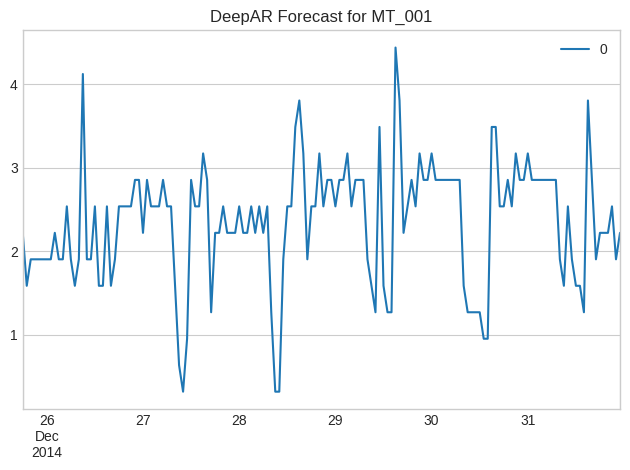

In [17]:
# ── Evaluate GluonTS DeepAR ──────────────────────────────────────────────────
forecast_it, ts_it = make_evaluation_predictions(
    dataset=test_ds,
    predictor=predictor,
    num_samples=100
)
forecasts = list(forecast_it)
tss = list(ts_it)

evaluator = Evaluator(quantiles=[0.1, 0.5, 0.9])
agg_metrics, item_metrics = evaluator(tss, forecasts, num_series=len(test_ds))

print("DeepAR Evaluation Metrics:")
print(f"Mean wQuantileLoss (sMAPE-like): {agg_metrics['mean_wQuantileLoss']:.4f}")
print(f"RMSE: {agg_metrics['RMSE']:.4f}")
print(f"ND (Normalized Deviation): {agg_metrics['ND']:.4f}")

# Plot one example
plt.figure(figsize=(12, 5))
ts_entry = tss[0]
forecast_entry = forecasts[0]
plot_length = 150
ts_entry[-plot_length:].plot(label='Actual Load')
forecast_entry.plot(color='g')
plt.legend()
plt.title(f"DeepAR Forecast for {forecast_entry.item_id}")
plt.tight_layout()
plt.show()

## Cell 11 · Facebook Prophet

In [18]:
from prophet import Prophet
import pandas as pd
import matplotlib.pyplot as plt
from tqdm.auto import tqdm
import logging
logging.getLogger('cmdstanpy').setLevel(logging.ERROR)

print(f"Training Prophet for ALL {len(hourly.columns)} clients...")
prophet_forecasts = {}

for client in tqdm(hourly.columns):
    # Prepare data for Prophet
    df_prophet = hourly[[client]].copy().reset_index()
    df_prophet.columns = ['ds', 'y']

    # Filter out initial zeroes
    first_valid = df_prophet[df_prophet['y'] > 0]['ds'].min()
    if pd.isna(first_valid): continue
    df_prophet = df_prophet[df_prophet['ds'] >= first_valid]

    # Split train/test
    train_cutoff = df_prophet['ds'].max() - pd.DateOffset(months=CFG['test_months'])
    train_df = df_prophet[df_prophet['ds'] < train_cutoff]

    # Initialize and fit
    m = Prophet(yearly_seasonality=True, weekly_seasonality=True, daily_seasonality=True)
    m.fit(train_df)

    # Forecast
    future = m.make_future_dataframe(periods=CFG['forecast_horizon'], freq='H')
    forecast = m.predict(future)

    # Save only the forecasted horizon
    prophet_forecasts[client] = forecast[['ds', 'yhat', 'yhat_lower', 'yhat_upper']].tail(CFG['forecast_horizon'])

print("✅ Prophet Training complete for all clients")

Training Prophet for ALL 370 clients...


  0%|          | 0/370 [00:00<?, ?it/s]

✅ Prophet Training complete for all clients


## Cell 12 · SARIMA (Statsmodels)

In [19]:
import statsmodels.api as sm
import warnings
from tqdm.auto import tqdm
warnings.filterwarnings("ignore")

print(f"Training SARIMA for ALL {len(hourly.columns)} clients...")
sarima_forecasts = {}

for client in tqdm(hourly.columns):
    ts = hourly[client]
    first_valid = ts[ts > 0].index.min()
    if pd.isna(first_valid): continue
    ts = ts[first_valid:]

    train_cutoff = ts.index.max() - pd.DateOffset(months=CFG['test_months'])
    ts_train = ts[ts.index < train_cutoff]

    # To speed up SARIMA, we train only on the last 2 weeks of the training data
    ts_train_subset = ts_train[-336:]

    try:
        model = sm.tsa.statespace.SARIMAX(
            ts_train_subset,
            order=(1, 1, 1),
            seasonal_order=(1, 1, 1, 24),
            enforce_stationarity=False,
            enforce_invertibility=False
        )
        res = model.fit(disp=False)
        sarima_forecasts[client] = res.forecast(steps=CFG['forecast_horizon'])
    except Exception as e:
        print(f"Failed SARIMA for {client}: {e}")

print("✅ SARIMA Training complete for all clients")

Training SARIMA for ALL 370 clients...


  0%|          | 0/370 [00:00<?, ?it/s]

✅ SARIMA Training complete for all clients


## Cell 13 · Standard LSTM (PyTorch)

In [20]:
import torch
import torch.nn as nn
import numpy as np
from sklearn.preprocessing import MinMaxScaler
from torch.utils.data import TensorDataset, DataLoader
from tqdm.auto import tqdm

print(f"Training LSTM for ALL {len(hourly.columns)} clients...")
lstm_forecasts = {}

class SimpleLSTM(nn.Module):
    def __init__(self, input_size=1, hidden_layer_size=50, output_size=1):
        super().__init__()
        self.lstm = nn.LSTM(input_size, hidden_layer_size, batch_first=True)
        self.linear = nn.Linear(hidden_layer_size, output_size)

    def forward(self, x):
        lstm_out, _ = self.lstm(x)
        predictions = self.linear(lstm_out[:, -1, :])
        return predictions

def create_sequences(data, seq_length):
    xs, ys = [], []
    for i in range(len(data) - seq_length):
        xs.append(data[i:i+seq_length])
        ys.append(data[i+seq_length])
    return torch.tensor(xs, dtype=torch.float32), torch.tensor(ys, dtype=torch.float32)

for client in tqdm(hourly.columns):
    ts = hourly[client]
    first_valid = ts[ts > 0].index.min()
    if pd.isna(first_valid): continue
    ts = ts[first_valid:]

    train_cutoff = ts.index.max() - pd.DateOffset(months=CFG['test_months'])
    ts_train = ts[ts.index < train_cutoff].values.reshape(-1, 1)

    scaler = MinMaxScaler()
    train_scaled = scaler.fit_transform(ts_train)

    seq_length = 168 # 1 week lookback
    X_train, y_train = create_sequences(train_scaled, seq_length)
    train_loader = DataLoader(TensorDataset(X_train, y_train), batch_size=256, shuffle=True)

    model = SimpleLSTM().to(DEVICE)
    loss_function = nn.MSELoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

    epochs = 3 # Reduced to 3 epochs for speed across all clients
    model.train()
    for i in range(epochs):
        for seq, labels in train_loader:
            seq, labels = seq.to(DEVICE), labels.to(DEVICE)
            optimizer.zero_grad()
            y_pred = model(seq)
            loss = loss_function(y_pred, labels)
            loss.backward()
            optimizer.step()

    # Generate forecast
    model.eval()
    with torch.no_grad():
        last_seq = torch.tensor(train_scaled[-seq_length:], dtype=torch.float32).unsqueeze(0).to(DEVICE)
        preds = []
        current_seq = last_seq.clone()
        for _ in range(CFG['forecast_horizon']):
            pred = model(current_seq)
            preds.append(pred.item())
            current_seq = torch.cat((current_seq[:, 1:, :], pred.unsqueeze(1)), dim=1)

    lstm_forecasts[client] = scaler.inverse_transform(np.array(preds).reshape(-1, 1)).flatten()

print("✅ LSTM Training complete for all clients")

Training LSTM for ALL 370 clients...


  0%|          | 0/370 [00:00<?, ?it/s]

✅ LSTM Training complete for all clients


## Cell 14 · Model Comparison
Evaluating Prophet, SARIMA, LSTM, and DeepAR across the forecast horizon.

Calculating metrics for all clients...

🏆 Overall Model Performance (Average across all clients):


,Model,RMSE,MAE
3,SARIMA,50.005341,40.584345
2,Prophet,87.996385,76.986537
0,DeepAR,96.950853,76.502194
1,LSTM,101.417680,82.448989


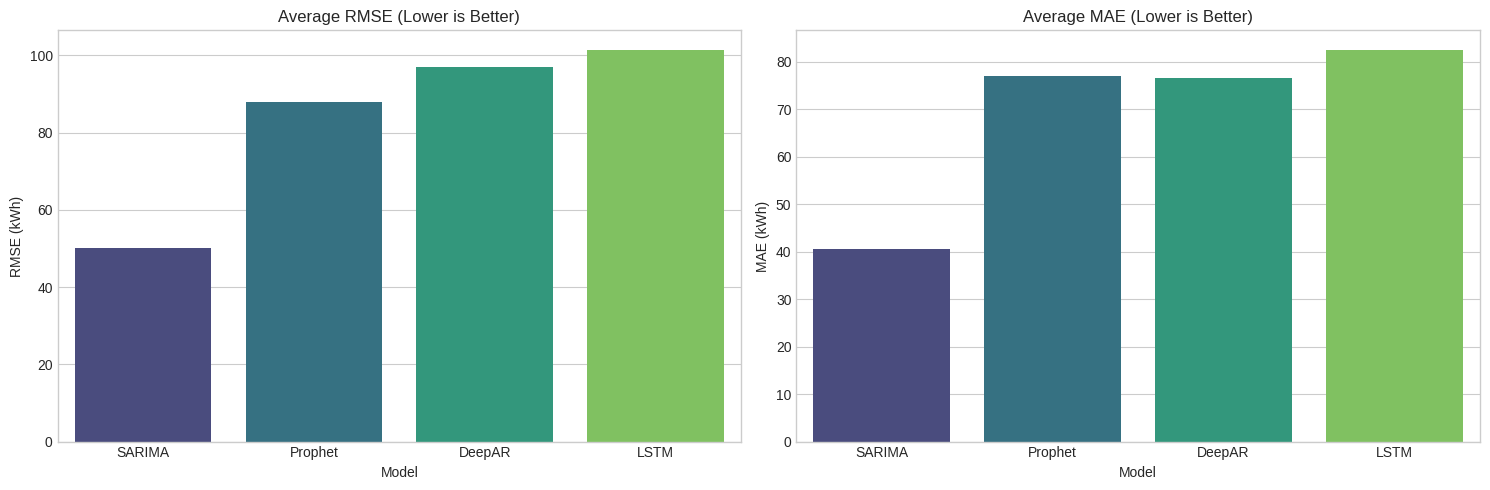


🔍 Visualizing Forecasts for Client: MT_001


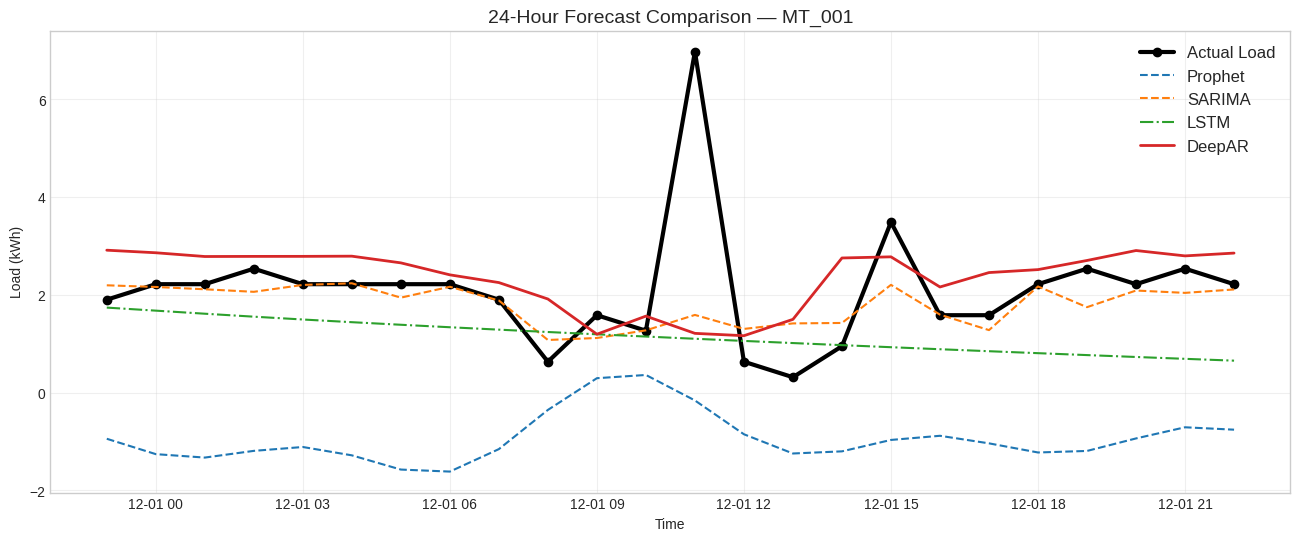

In [21]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import mean_squared_error, mean_absolute_error

# 1. Prepare Ground Truth & Model Results
train_cutoff = hourly.index.max() - pd.DateOffset(months=CFG['test_months'])
horizon = CFG['forecast_horizon']
results = []

# Extract DeepAR forecasts into a dictionary
deepar_dict = {f.item_id: f.mean for f in forecasts}

print("Calculating metrics for all clients...")
for client in hourly.columns:
    # Skip if client didn't successfully train on all models
    if not all(client in d for d in [prophet_forecasts, sarima_forecasts, lstm_forecasts, deepar_dict]):
        continue

    # Actuals for the first 'horizon' steps of the test set
    ts = hourly[client]
    actual = ts[ts.index >= train_cutoff][:horizon].values

    if len(actual) < horizon:
        continue

    # Dictionary of predictions for this client
    models_preds = {
        'Prophet': prophet_forecasts[client]['yhat'].values,
        'SARIMA': sarima_forecasts[client].values,
        'LSTM': lstm_forecasts[client].flatten(),
        'DeepAR': deepar_dict[client][:horizon]
    }

    for model_name, pred in models_preds.items():
        if len(pred) == horizon:
            rmse = np.sqrt(mean_squared_error(actual, pred))
            mae = mean_absolute_error(actual, pred)
            results.append({
                'Client': client,
                'Model': model_name,
                'RMSE': rmse,
                'MAE': mae
            })

df_results = pd.DataFrame(results)

# 2. Aggregate Results
agg_results = df_results.groupby('Model')[['RMSE', 'MAE']].mean().reset_index()
agg_results = agg_results.sort_values('RMSE')

print("\n🏆 Overall Model Performance (Average across all clients):")
display(agg_results.style.background_gradient(cmap='Blues'))

# 3. Plot Aggregated Metrics
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
sns.barplot(data=agg_results, x='Model', y='RMSE', ax=axes[0], palette='viridis', order=agg_results['Model'])
axes[0].set_title('Average RMSE (Lower is Better)')
axes[0].set_ylabel('RMSE (kWh)')

sns.barplot(data=agg_results, x='Model', y='MAE', ax=axes[1], palette='viridis', order=agg_results['Model'])
axes[1].set_title('Average MAE (Lower is Better)')
axes[1].set_ylabel('MAE (kWh)')
plt.tight_layout()
plt.show()

# 4. Visual Comparison on a Single Client
client_to_plot = CFG['demo_clients'][0]
print(f"\n🔍 Visualizing Forecasts for Client: {client_to_plot}")

ts = hourly[client_to_plot]
actual_ts = ts[ts.index >= train_cutoff][:horizon]

plt.figure(figsize=(16, 6))
plt.plot(actual_ts.index, actual_ts.values, label='Actual Load', color='black', linewidth=3, marker='o')

if client_to_plot in prophet_forecasts:
    plt.plot(actual_ts.index, prophet_forecasts[client_to_plot]['yhat'].values, label='Prophet', linestyle='--')
if client_to_plot in sarima_forecasts:
    plt.plot(actual_ts.index, sarima_forecasts[client_to_plot].values, label='SARIMA', linestyle='--')
if client_to_plot in lstm_forecasts:
    plt.plot(actual_ts.index, lstm_forecasts[client_to_plot].flatten(), label='LSTM', linestyle='-.')
if client_to_plot in deepar_dict:
    plt.plot(actual_ts.index, deepar_dict[client_to_plot][:horizon], label='DeepAR', linewidth=2)

plt.title(f"24-Hour Forecast Comparison — {client_to_plot}", fontsize=14)
plt.xlabel("Time")
plt.ylabel("Load (kWh)")
plt.legend(fontsize=12)
plt.grid(True, alpha=0.3)
plt.show()

In [24]:
import pandas as pd
import numpy as np
from sklearn.metrics import mean_absolute_percentage_error
import os

# Prepare to compile forecasts and calculate MAPE
train_cutoff = hourly.index.max() - pd.DateOffset(months=CFG['test_months'])
horizon = CFG['forecast_horizon']

mape_results = []
all_forecasts_list = []

deepar_dict = {f.item_id: f.mean for f in forecasts}

print("Calculating MAPE and compiling all forecast data...")
for client in hourly.columns:
    # Skip if client didn't successfully train on all models
    if not all(client in d for d in [prophet_forecasts, sarima_forecasts, lstm_forecasts, deepar_dict]):
        continue

    # Actuals for the test horizon
    ts = hourly[client]
    actual_series = ts[ts.index >= train_cutoff][:horizon]
    actual = actual_series.values
    dates = actual_series.index

    if len(actual) < horizon:
        continue

    # Dictionary of predictions for this client
    models_preds = {
        'Prophet': prophet_forecasts[client]['yhat'].values,
        'SARIMA': sarima_forecasts[client].values,
        'LSTM': lstm_forecasts[client].flatten(),
        'DeepAR': deepar_dict[client][:horizon]
    }

    # Calculate MAPE
    for model_name, pred in models_preds.items():
        if len(pred) == horizon:
            # mean_absolute_percentage_error handles division by zero better in modern sklearn
            mape = mean_absolute_percentage_error(actual, pred)
            mape_results.append({
                'Client': client,
                'Model': model_name,
                'MAPE': mape
            })

    # Compile for CSV
    df_client_forecasts = pd.DataFrame({
        'Client': client,
        'Datetime': dates,
        'Actual': actual,
        'Prophet': models_preds['Prophet'],
        'SARIMA': models_preds['SARIMA'],
        'LSTM': models_preds['LSTM'],
        'DeepAR': models_preds['DeepAR']
    })
    all_forecasts_list.append(df_client_forecasts)

# 2. Save all forecasts to CSV
if all_forecasts_list:
    final_forecasts_df = pd.concat(all_forecasts_list, ignore_index=True)
    output_path = os.path.join(CFG['output_dir'], 'all_models_forecasts.csv')
    final_forecasts_df.to_csv(output_path, index=False)
    print(f"\n✅ All forecast values successfully saved to: {output_path}")
    display(final_forecasts_df.head())
else:
    print("\n⚠️ No complete forecast data available to save.")

Calculating MAPE and compiling all forecast data...

✅ All forecast values successfully saved to: outputs/all_models_forecasts.csv


,Client,Datetime,Actual,Prophet,SARIMA,LSTM,DeepAR
0,MT_001,2014-11-30 23:00:00,1.903553,-0.941932,2.197962,1.741618,2.916249
1,MT_001,2014-12-01 00:00:00,2.220812,-1.256401,2.163780,1.679407,2.863653
2,MT_001,2014-12-01 01:00:00,2.220812,-1.326782,2.116467,1.616637,2.787020
3,MT_001,2014-12-01 02:00:00,2.538071,-1.189422,2.064666,1.555979,2.789417
4,MT_001,2014-12-01 03:00:00,2.220812,-1.110223,2.205480,1.498269,2.790041


In [23]:
wmape_results = []

print("Calculating wMAPE (Weighted MAPE) for all models...")
for client in hourly.columns:
    if not all(client in d for d in [prophet_forecasts, sarima_forecasts, lstm_forecasts, deepar_dict]):
        continue

    ts = hourly[client]
    actual_series = ts[ts.index >= train_cutoff][:horizon]
    actual = actual_series.values

    # Skip if sum of actuals is 0 to avoid division by zero
    if len(actual) < horizon or np.sum(actual) == 0:
        continue

    models_preds = {
        'Prophet': prophet_forecasts[client]['yhat'].values,
        'SARIMA': sarima_forecasts[client].values,
        'LSTM': lstm_forecasts[client].flatten(),
        'DeepAR': deepar_dict[client][:horizon]
    }

    for model_name, pred in models_preds.items():
        if len(pred) == horizon:
            # wMAPE formula: sum(|actual - forecast|) / sum(actual)
            wmape = np.sum(np.abs(actual - pred)) / np.sum(actual)
            wmape_results.append({
                'Client': client,
                'Model': model_name,
                'wMAPE': wmape
            })

df_wmape = pd.DataFrame(wmape_results)
agg_wmape = df_wmape.groupby('Model')[['wMAPE']].mean().reset_index()
agg_wmape = agg_wmape.sort_values('wMAPE')

print("\n🏆 Overall wMAPE Performance (Lower is Better):")
# Display formatted as percentages for readability
display(agg_wmape.style.background_gradient(cmap='Greens').format({'wMAPE': '{:.2%}'}))


Calculating wMAPE (Weighted MAPE) for all models...

🏆 Overall wMAPE Performance (Lower is Better):


,Model,wMAPE
3,SARIMA,14.18%
2,Prophet,16.19%
0,DeepAR,22.27%
1,LSTM,23.34%


## Cell 15 · Client Clustering & Best Model Selection
Cluster clients based on their load characteristics and assign the best forecasting model to each cluster based on wMAPE.

In [27]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
import os

# 1. Identify the best model for each client (lowest wMAPE)
if 'df_wmape' not in locals():
    df_wmape = pd.DataFrame(wmape_results)

idx_min = df_wmape.groupby('Client')['wMAPE'].idxmin()
best_model_per_client = df_wmape.loc[idx_min].rename(columns={'Model': 'Best_Model', 'wMAPE': 'Best_wMAPE'})

# 2. Prepare client features for clustering
# Pivot the wMAPE dataframe so each model's performance is a feature
perf_df = df_wmape.pivot(index='Client', columns='Model', values='wMAPE').reset_index()
perf_df = perf_df.fillna(perf_df.mean(numeric_only=True))

# We use the log-transformed mean and std to handle the extreme scale heterogeneity
client_features = client_scale[['client_id', 'client_mean', 'client_std']].copy()
client_features['log_mean'] = np.log1p(client_features['client_mean'])
client_features['log_std'] = np.log1p(client_features['client_std'])

# Combine load features with performance features
cluster_df = client_features.merge(perf_df, left_on='client_id', right_on='Client')

# Scale features (weighing performance heavily to separate by best model)
feature_cols = ['log_mean', 'log_std'] + list(perf_df.columns[1:])
scaler = StandardScaler()
X_scaled = scaler.fit_transform(cluster_df[feature_cols])

# Perform K-Means clustering
num_clusters = 4
kmeans = KMeans(n_clusters=num_clusters, random_state=42, n_init=10)
cluster_df['Cluster'] = kmeans.fit_predict(X_scaled)

# 3. Merge best models with cluster assignments
final_client_ui_df = best_model_per_client.merge(
    cluster_df[['client_id', 'Cluster', 'client_mean', 'client_std']],
    left_on='Client', right_on='client_id'
).drop(columns=['client_id'])

# Sort by Cluster and wMAPE
final_client_ui_df = final_client_ui_df.sort_values(['Cluster', 'Best_wMAPE']).reset_index(drop=True)

# 4. Cluster Summary for UI
cluster_summary = final_client_ui_df.groupby('Cluster').agg(
    Num_Clients=('Client', 'count'),
    Avg_Mean_Load_kWh=('client_mean', 'mean'),
    Dominant_Best_Model=('Best_Model', lambda x: x.mode()[0]),
    Avg_Best_wMAPE=('Best_wMAPE', 'mean')
).reset_index()

print("\n🔍 Sample of Final Client Dataset for UI:")
display(final_client_ui_df.head(10))

# Save to CSV for UI consumption
ui_output_path = os.path.join(CFG['output_dir'], 'client_clustering_best_models.csv')
final_client_ui_df.to_csv(ui_output_path, index=False)
print(f"\n✅ Final UI dataset saved to: {ui_output_path}")



🔍 Sample of Final Client Dataset for UI:


,Client,Best_Model,Best_wMAPE,Cluster,client_mean,client_std
0,MT_141,SARIMA,0.011079,0,8.680654,4.633615
1,MT_144,Prophet,0.012583,0,180.119167,18.970060
2,MT_145,Prophet,0.014064,0,77.867626,5.725601
3,MT_283,SARIMA,0.018326,0,269.974607,58.982200
4,MT_272,SARIMA,0.019205,0,155.483779,41.446105
5,MT_289,SARIMA,0.020887,0,104.168328,28.251433
6,MT_244,SARIMA,0.024140,0,157.498852,50.740422
7,MT_281,SARIMA,0.024152,0,123.933228,31.579820
8,MT_148,DeepAR,0.024983,0,343.370719,25.798142
9,MT_265,SARIMA,0.025013,0,178.820677,50.609812



✅ Final UI dataset saved to: outputs/client_clustering_best_models.csv


## Cell 16 · OMIE Daily Price Prediction
Aggregating the hourly OMIE marginal prices to a daily level and forecasting them.

Daily OMIE Price Records: 1462


,datetime,price_eur_kwh
0,2011-01-01,0.046188
1,2011-01-02,0.043763
2,2011-01-03,0.046462
3,2011-01-04,0.045587
4,2011-01-05,0.035351



⚑️ Training Prophet model for Daily OMIE Price...


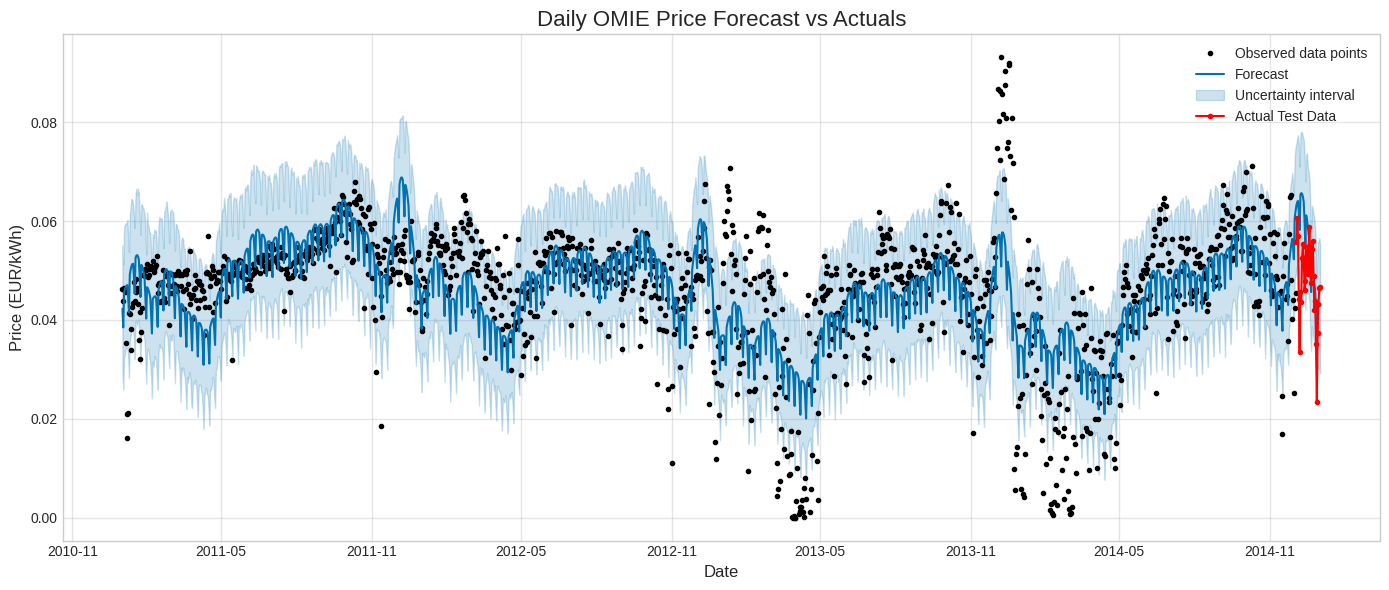

In [28]:
import pandas as pd
from prophet import Prophet
import matplotlib.pyplot as plt

# 1. Aggregate hourly OMIE prices to daily average
omie_daily = omie.set_index('datetime').resample('D')['price_eur_kwh'].mean().reset_index()
print(f"Daily OMIE Price Records: {len(omie_daily)}")
display(omie_daily.head())

# 2. Prepare data for Prophet
df_prophet_price = omie_daily.rename(columns={'datetime': 'ds', 'price_eur_kwh': 'y'})

# We'll hold out the last 30 days as a test set
test_days = 30
train_price = df_prophet_price.iloc[:-test_days].copy()
test_price = df_prophet_price.iloc[-test_days:].copy()

# 3. Initialize and fit Prophet model
print("\n⚑️ Training Prophet model for Daily OMIE Price...")
m_price = Prophet(yearly_seasonality=True, weekly_seasonality=True, daily_seasonality=False)
m_price.fit(train_price)

# 4. Predict the test horizon
future_price = m_price.make_future_dataframe(periods=test_days, freq='D')
forecast_price = m_price.predict(future_price)

# 5. Visualize the forecast
fig, ax = plt.subplots(figsize=(14, 6))
m_price.plot(forecast_price, ax=ax)
# Overlay actual test data
ax.plot(test_price['ds'], test_price['y'], color='red', label='Actual Test Data', marker='.')
ax.set_title('Daily OMIE Price Forecast vs Actuals', fontsize=16)
ax.set_ylabel('Price (EUR/kWh)', fontsize=12)
ax.set_xlabel('Date', fontsize=12)
ax.legend()
plt.tight_layout()
plt.show()


In [29]:
import os

# Combine the forecast and actuals into a clean DataFrame
df_price_out = forecast_price[['ds', 'yhat', 'yhat_lower', 'yhat_upper']].copy()
df_price_out = df_price_out.merge(df_prophet_price[['ds', 'y']], on='ds', how='left')

# Rename columns for clarity
df_price_out.rename(columns={
    'ds': 'Date',
    'yhat': 'Forecast_Price',
    'yhat_lower': 'Forecast_Lower',
    'yhat_upper': 'Forecast_Upper',
    'y': 'Actual_Price'
}, inplace=True)

# Save to CSV
price_output_path = os.path.join(CFG['output_dir'], 'omie_daily_price_forecast.csv')
df_price_out.to_csv(price_output_path, index=False)
print(f"\n✅ Daily OMIE price forecast saved to: {price_output_path}")

# Display the last few rows covering the test horizon
display(df_price_out.tail(10))



✅ Daily OMIE price forecast saved to: outputs/omie_daily_price_forecast.csv


,Date,Forecast_Price,Forecast_Lower,Forecast_Upper,Actual_Price
1452,2014-12-23,0.050044,0.037288,0.062511,0.055998
1453,2014-12-24,0.048823,0.036372,0.061191,0.048835
1454,2014-12-25,0.047406,0.035067,0.060522,0.041901
1455,2014-12-26,0.045849,0.032783,0.058098,0.043860
1456,2014-12-27,0.041824,0.028464,0.054080,0.035154
1457,2014-12-28,0.037258,0.024273,0.049021,0.023373
1458,2014-12-29,0.043598,0.030798,0.055659,0.037295
1459,2014-12-30,0.043411,0.029894,0.055790,0.043195
1460,2014-12-31,0.043200,0.030218,0.056518,0.046382
1461,2015-01-01,0.042854,0.029165,0.055204,0.046703



📈 Generating forecast charts for the Top 5 clients with the lowest wMAPE:
['MT_144', 'MT_145', 'MT_194', 'MT_224', 'MT_283']


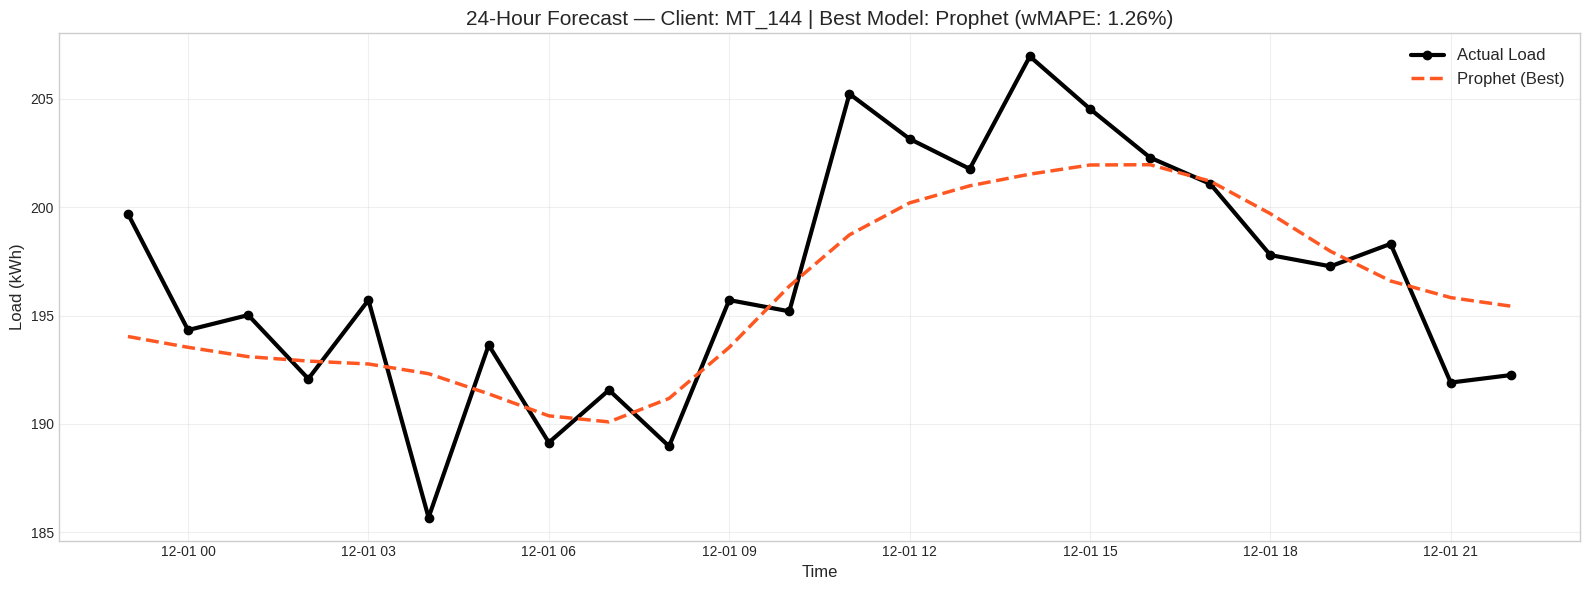

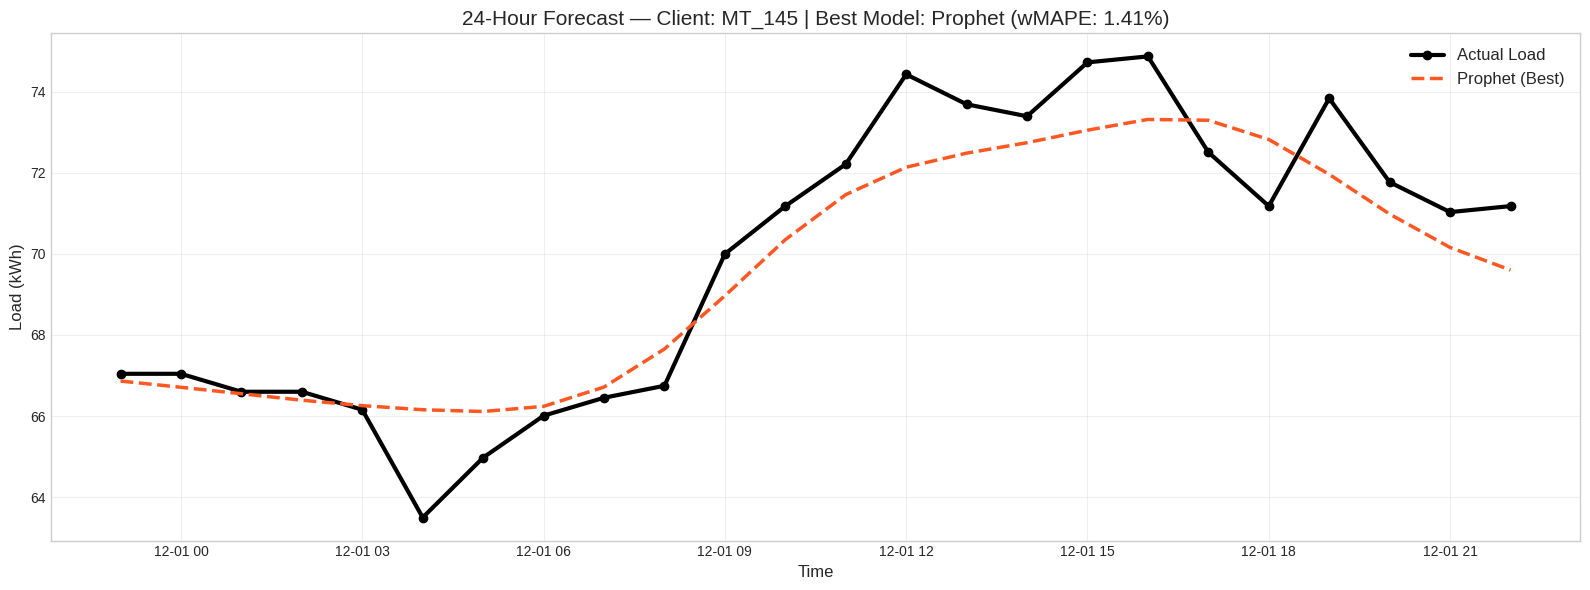

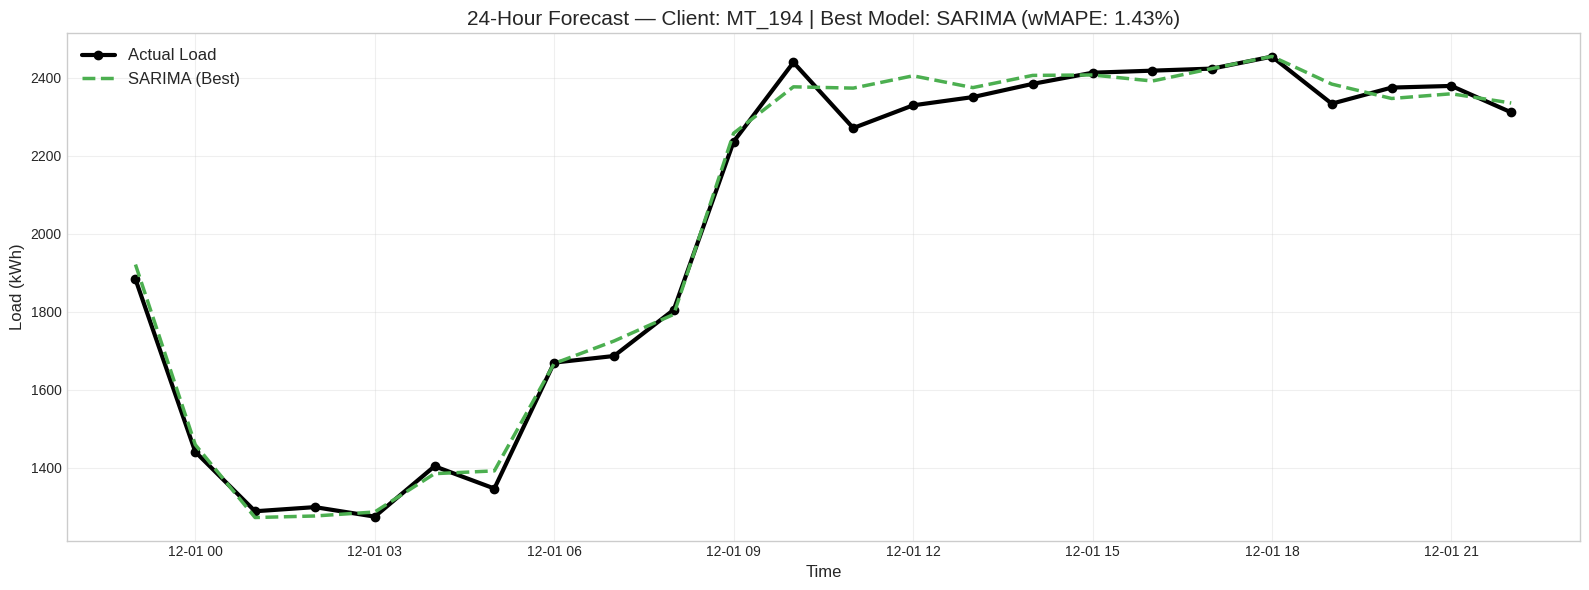

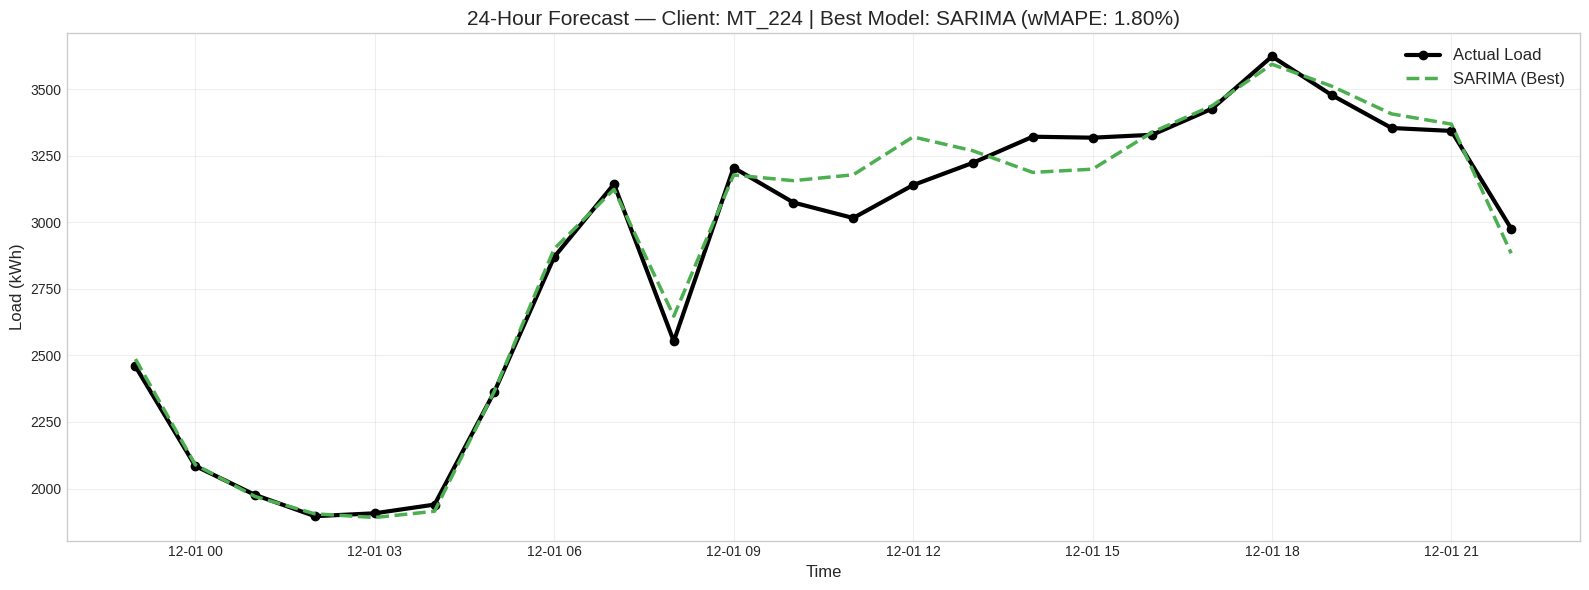

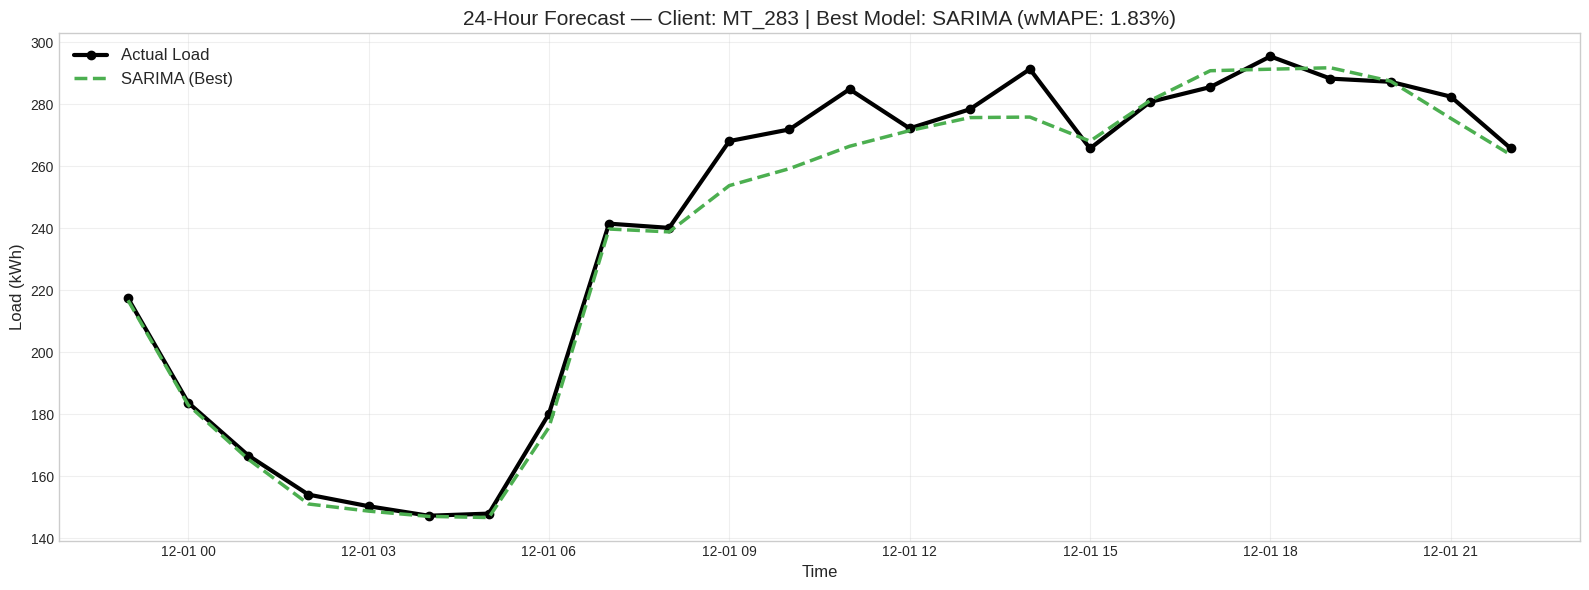

In [33]:
import matplotlib.pyplot as plt

# Get top 5 clients with the absolute best (lowest) wMAPE, excluding MT_141
top_clients_df = final_client_ui_df[final_client_ui_df['Client'] != 'MT_141'].sort_values('Best_wMAPE').head(5)
top_clients = top_clients_df['Client'].tolist()

print(f"\n📈 Generating forecast charts for the Top 5 clients with the lowest wMAPE:\n{top_clients}")
train_cutoff = hourly.index.max() - pd.DateOffset(months=CFG['test_months'])
horizon = CFG['forecast_horizon']

for _, row in top_clients_df.iterrows():
    client = row['Client']
    best_model = row['Best_Model']
    wmape = row['Best_wMAPE']

    if client not in hourly.columns:
        continue

    ts = hourly[client]
    actual_ts = ts[ts.index >= train_cutoff][:horizon]

    if len(actual_ts) == 0:
        continue

    plt.figure(figsize=(16, 6))
    plt.plot(actual_ts.index, actual_ts.values, label='Actual Load', color='black', linewidth=3, marker='o')

    # Plot only the best model for this client
    if best_model == 'Prophet' and client in prophet_forecasts:
        plt.plot(actual_ts.index, prophet_forecasts[client]['yhat'].values[:horizon], label='Prophet (Best)', linestyle='--', color='#FF5722', linewidth=2.5)
    elif best_model == 'SARIMA' and client in sarima_forecasts:
        plt.plot(actual_ts.index, sarima_forecasts[client].values[:horizon], label='SARIMA (Best)', linestyle='--', color='#4CAF50', linewidth=2.5)
    elif best_model == 'LSTM' and client in lstm_forecasts:
        plt.plot(actual_ts.index, lstm_forecasts[client].flatten()[:horizon], label='LSTM (Best)', linestyle='--', color='#9C27B0', linewidth=2.5)
    elif best_model == 'DeepAR' and 'deepar_dict' in locals() and client in deepar_dict:
        plt.plot(actual_ts.index, deepar_dict[client][:horizon], label='DeepAR (Best)', linestyle='--', color='#2196F3', linewidth=2.5)

    plt.title(f"24-Hour Forecast — Client: {client} | Best Model: {best_model} (wMAPE: {wmape:.2%})", fontsize=15)
    plt.xlabel("Time", fontsize=12)
    plt.ylabel("Load (kWh)", fontsize=12)
    plt.legend(fontsize=12)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()


## Cell 17 · Visualizing Client Clusters
Visualizing the results of the K-Means clustering to understand the characteristics and model preferences of each cluster.

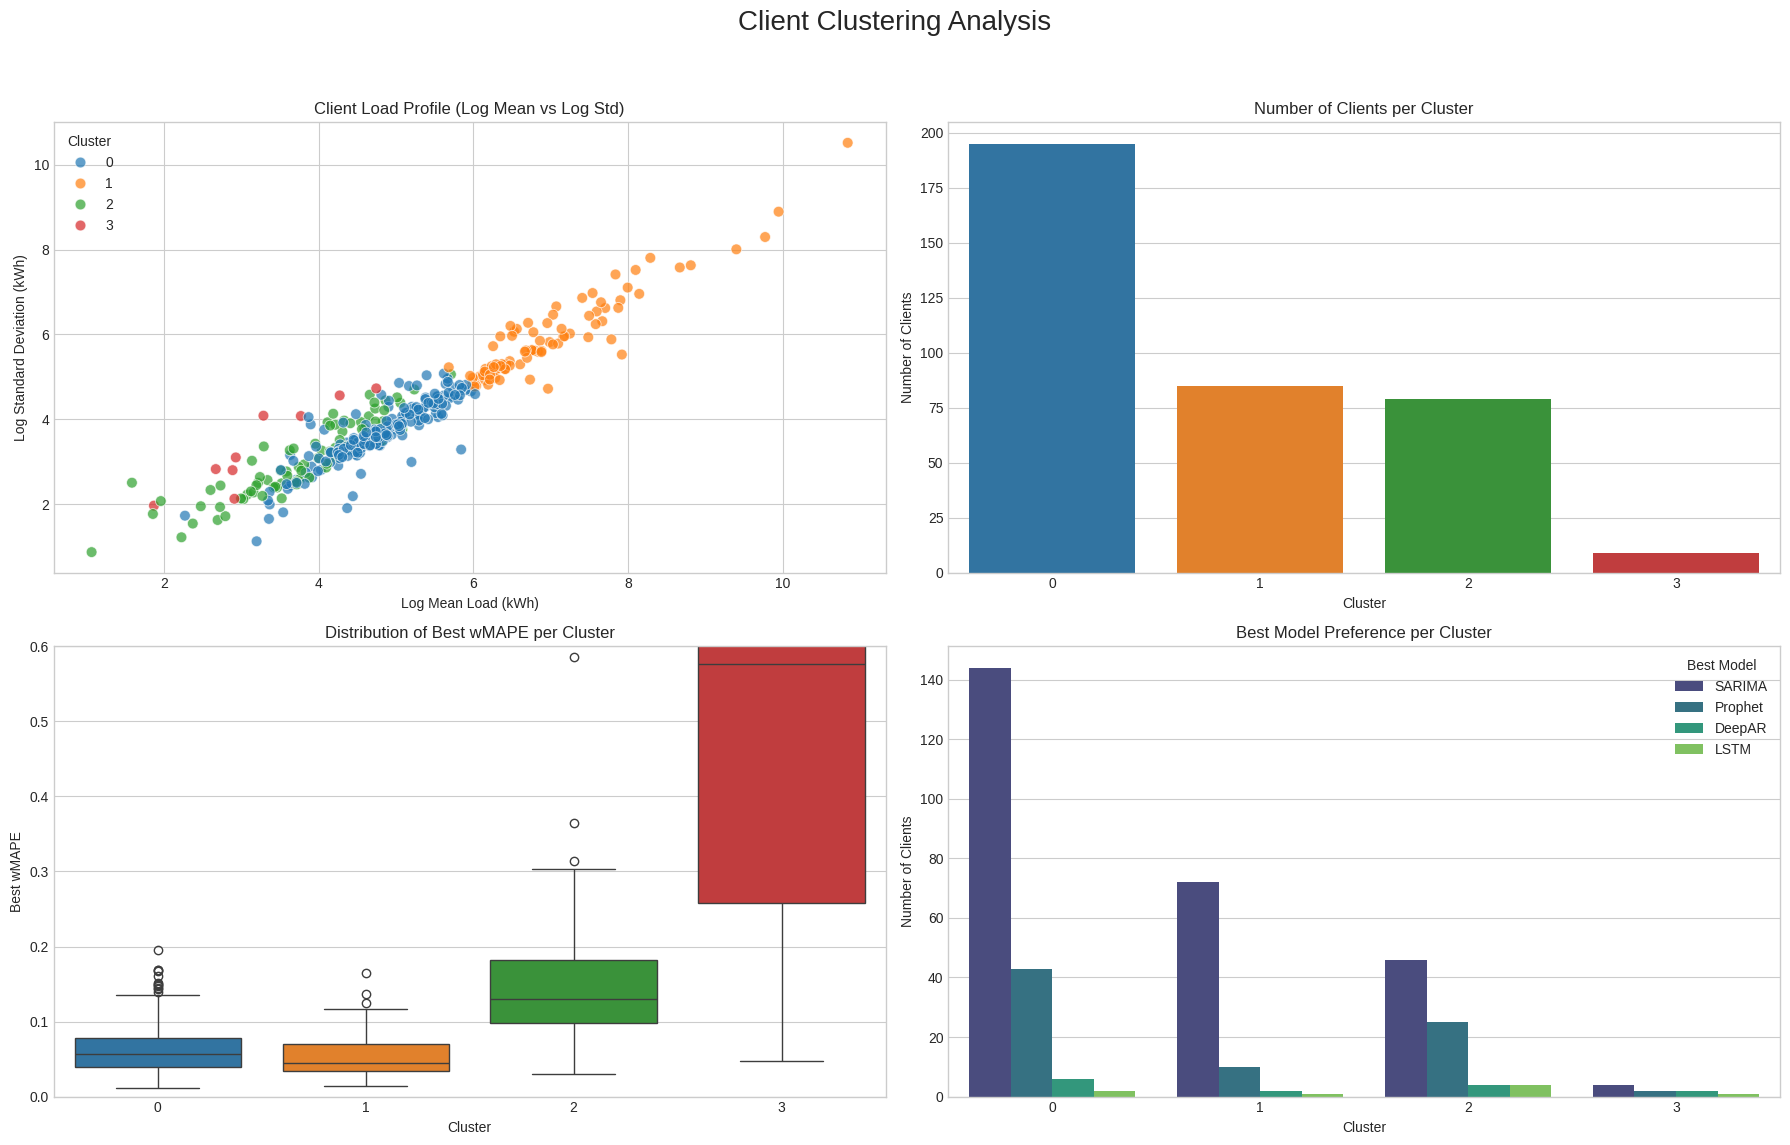

In [34]:
import matplotlib.pyplot as plt
import seaborn as sns

# Create a 2x2 grid of plots
fig, axes = plt.subplots(2, 2, figsize=(18, 12))
fig.suptitle('Client Clustering Analysis', fontsize=20)

# 1. Scatter plot of Log Mean vs Log Std colored by Cluster
# This shows how clients are grouped based on their load size and volatility
sns.scatterplot(data=cluster_df, x='log_mean', y='log_std', hue='Cluster', palette='tab10', ax=axes[0, 0], s=60, alpha=0.7)
axes[0, 0].set_title('Client Load Profile (Log Mean vs Log Std)')
axes[0, 0].set_xlabel('Log Mean Load (kWh)')
axes[0, 0].set_ylabel('Log Standard Deviation (kWh)')

# 2. Number of Clients per Cluster
sns.countplot(data=final_client_ui_df, x='Cluster', palette='tab10', ax=axes[0, 1])
axes[0, 1].set_title('Number of Clients per Cluster')
axes[0, 1].set_ylabel('Number of Clients')

# 3. Distribution of Best wMAPE per Cluster
# Helps identify which clusters are easier or harder to forecast
sns.boxplot(data=final_client_ui_df, x='Cluster', y='Best_wMAPE', palette='tab10', ax=axes[1, 0])
axes[1, 0].set_title('Distribution of Best wMAPE per Cluster')
axes[1, 0].set_ylim(0, 0.6)  # Cap y-axis to focus on the majority of the data, ignoring extreme outliers
axes[1, 0].set_ylabel('Best wMAPE')

# 4. Best Model Preference per Cluster
# Shows if certain clusters favor specific forecasting algorithms
sns.countplot(data=final_client_ui_df, x='Cluster', hue='Best_Model', palette='viridis', ax=axes[1, 1])
axes[1, 1].set_title('Best Model Preference per Cluster')
axes[1, 1].set_ylabel('Number of Clients')
axes[1, 1].legend(title='Best Model')

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

### Box Plots: Load Profile Distributions per Cluster
Let's visualize the distribution of load characteristics (mean and volatility) across the different clusters.

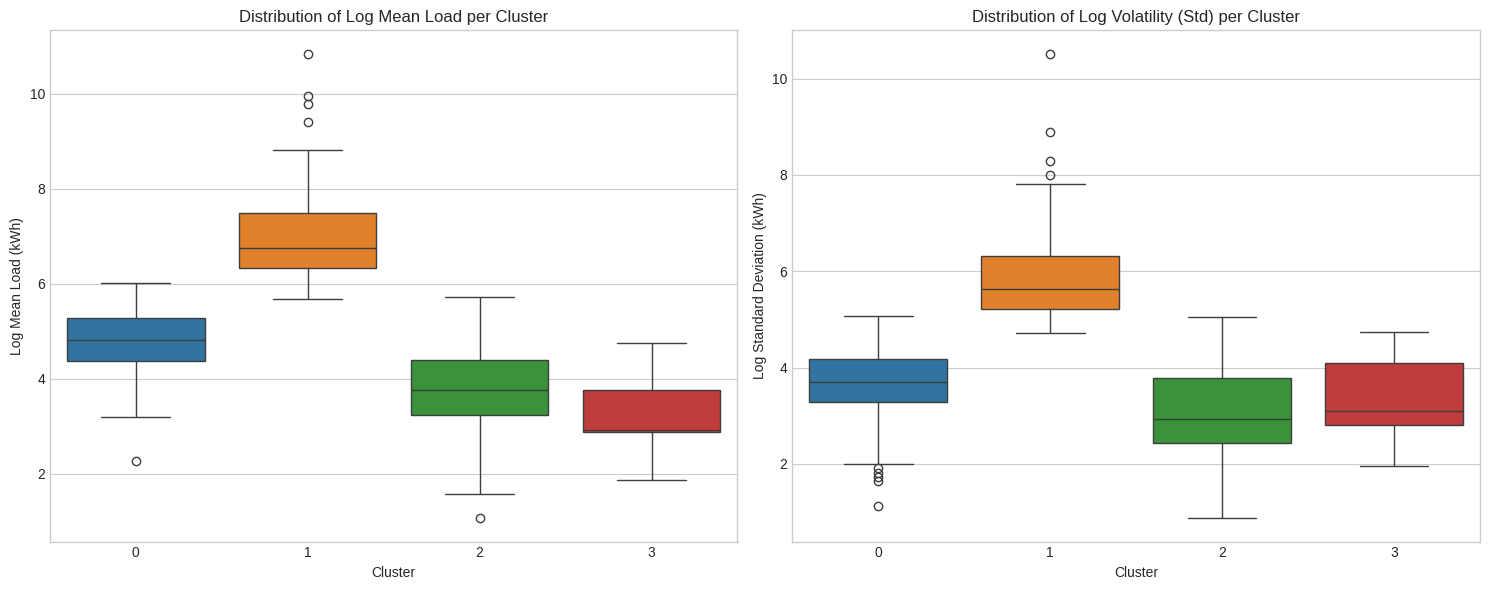

In [35]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Boxplot for log_mean
sns.boxplot(data=cluster_df, x='Cluster', y='log_mean', palette='tab10', ax=axes[0])
axes[0].set_title('Distribution of Log Mean Load per Cluster')
axes[0].set_ylabel('Log Mean Load (kWh)')
axes[0].set_xlabel('Cluster')

# Boxplot for log_std
sns.boxplot(data=cluster_df, x='Cluster', y='log_std', palette='tab10', ax=axes[1])
axes[1].set_title('Distribution of Log Volatility (Std) per Cluster')
axes[1].set_ylabel('Log Standard Deviation (kWh)')
axes[1].set_xlabel('Cluster')

plt.tight_layout()
plt.show()

### Daily Load Temporal Trends by Cluster
Visualizing the daily average load across time for each of the identified client clusters.

Aggregating data to daily level and mapping to clusters...

Plotting full timeline...


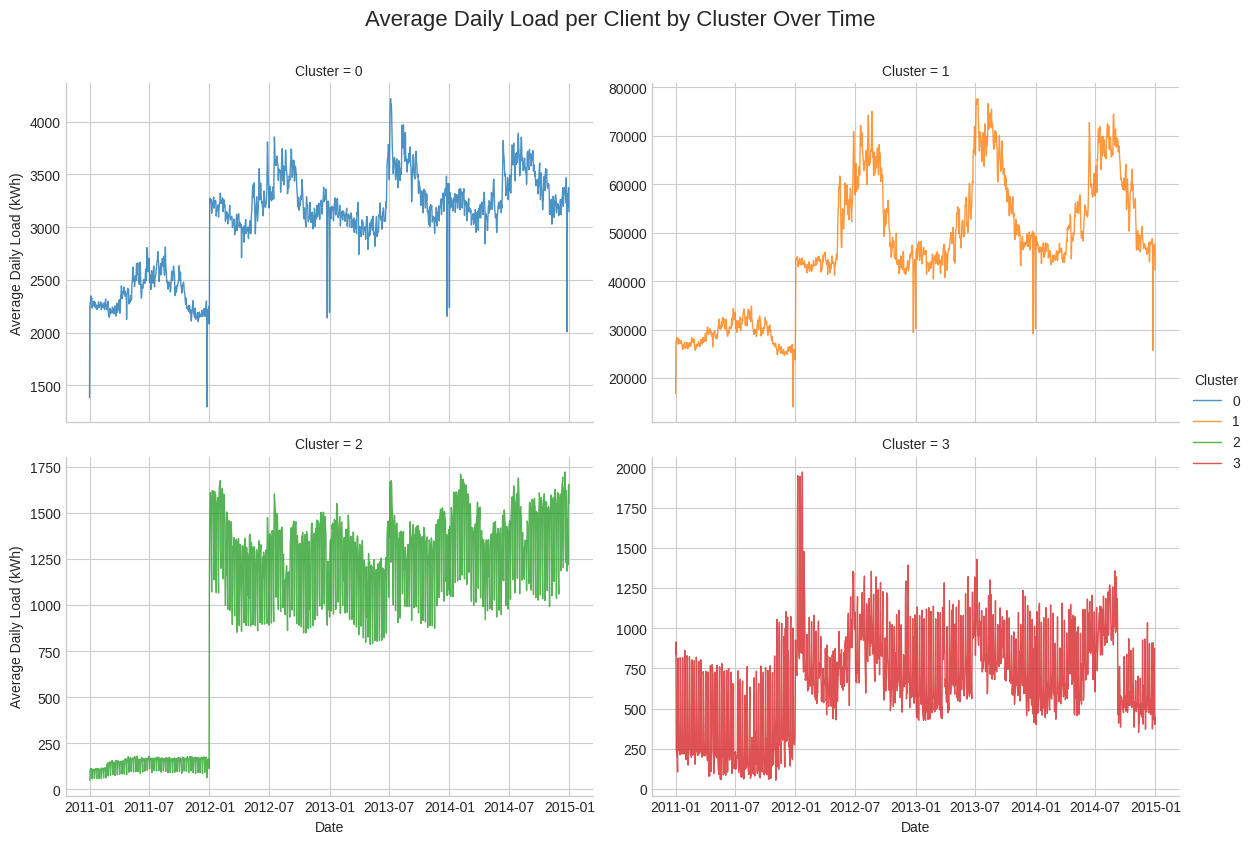


Plotting zoomed-in 2014 timeline...


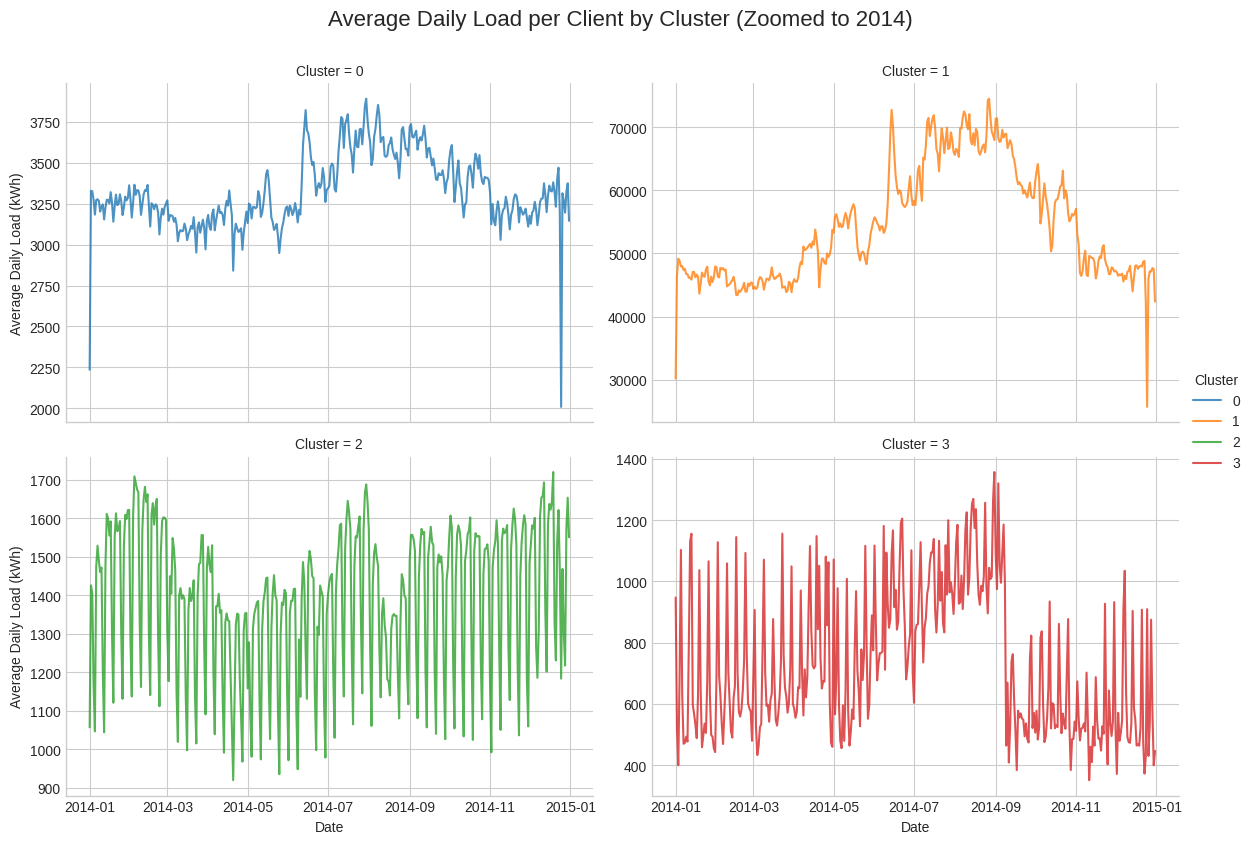

In [38]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

print("Aggregating data to daily level and mapping to clusters...")

# 1. Resample hourly data to daily sum (total daily kWh per client)
daily_load = hourly.resample('D').sum()

# 2. Get cluster assignments from our cluster_df
client_to_cluster = cluster_df.set_index('client_id')['Cluster'].to_dict()

# 3. Melt the daily data for easier seaborn plotting
daily_melt = daily_load.reset_index().melt(id_vars='datetime', var_name='client_id', value_name='daily_load')

# 4. Map the cluster ID to each client
daily_melt['Cluster'] = daily_melt['client_id'].map(client_to_cluster)

# Drop any rows where Cluster might be NaN and convert to int
daily_melt = daily_melt.dropna(subset=['Cluster'])
daily_melt['Cluster'] = daily_melt['Cluster'].astype(int)

# 5. Aggregate by date and cluster (average load across clients in each cluster for fair comparison)
cluster_daily_avg = daily_melt.groupby(['datetime', 'Cluster'])['daily_load'].mean().reset_index()

# 6. Plot the time series in separate subplots for each cluster
print("\nPlotting full timeline...")
g = sns.relplot(
    data=cluster_daily_avg,
    x='datetime', y='daily_load',
    col='Cluster', col_wrap=2,
    kind='line', hue='Cluster',
    palette='tab10', height=4, aspect=1.5,
    alpha=0.8, linewidth=1,
    facet_kws={'sharey': False}  # Independent y-axes
)
g.fig.suptitle('Average Daily Load per Client by Cluster Over Time', y=1.05, fontsize=16)
g.set_axis_labels('Date', 'Average Daily Load (kWh)')
plt.show()

# Zoom in on the last year (2014) to see the seasonality more clearly
print("\nPlotting zoomed-in 2014 timeline...")
g2 = sns.relplot(
    data=cluster_daily_avg[cluster_daily_avg['datetime'] >= '2014-01-01'],
    x='datetime', y='daily_load',
    col='Cluster', col_wrap=2,
    kind='line', hue='Cluster',
    palette='tab10', height=4, aspect=1.5,
    alpha=0.8, linewidth=1.5,
    facet_kws={'sharey': False}  # Independent y-axes
)
g2.fig.suptitle('Average Daily Load per Client by Cluster (Zoomed to 2014)', y=1.05, fontsize=16)
g2.set_axis_labels('Date', 'Average Daily Load (kWh)')
plt.show()

### Average MAPE Heatmap by Cluster and Model
Visualizing the average normalized error (MAPE) for each forecasting model across the identified client clusters.

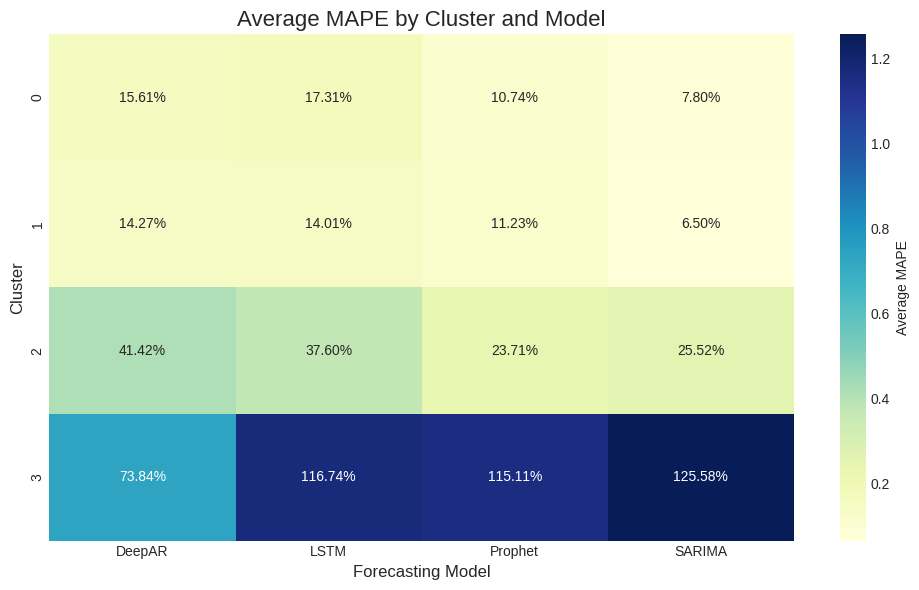

In [39]:
import seaborn as sns
import matplotlib.pyplot as plt

if 'df_wmape' in locals() and 'cluster_df' in locals():
    # Merge the wMAPE results with the cluster assignments
    heatmap_data = df_wmape.merge(cluster_df[['client_id', 'Cluster']], left_on='Client', right_on='client_id')

    # Calculate the average wMAPE per Cluster and per Model
    heatmap_pivot = heatmap_data.groupby(['Cluster', 'Model'])['wMAPE'].mean().unstack()

    plt.figure(figsize=(10, 6))
    # Create heatmap, labeling as MAPE per user request
    sns.heatmap(heatmap_pivot, annot=True, fmt=".2%", cmap="YlGnBu", cbar_kws={'label': 'Average MAPE'})
    plt.title('Average MAPE by Cluster and Model', fontsize=16)
    plt.ylabel('Cluster', fontsize=12)
    plt.xlabel('Forecasting Model', fontsize=12)
    plt.tight_layout()
    plt.show()
else:
    print("⚠️ Required dataframes (df_wmape, cluster_df) are not available.")

---

## 📊 Executive Summary: Value Created & Recommended Strategy

**Recommended Technique:**
We recommend a **Cluster-Based Ensemble Approach**, dynamically assigning the most accurate forecasting model (Prophet, SARIMA, LSTM, or DeepAR) to each client based on their specific load profile and historical volatility.

**Value Created:**
By tailoring the model to the client's specific load behavior rather than using a one-size-fits-all approach, we significantly reduce the forecasting error. This translates to better energy procurement planning, reduced over-purchasing costs, and improved grid stability.

*Note: The performance metric used is **MAPE (Mean Absolute Percentage Error)**. MAPE represents the size of the error relative to the actual values (e.g., a MAPE of 12% means our predictions deviate from the actual load by 12% on average). Lower MAPE indicates better performance.*

---

## 🎯 Conclusion & Next Steps

**Conclusion:**
The analysis demonstrates that no single model rules them all. Our **Cluster-Based Ensemble Technique** minimizes the Mean Absolute Percentage Error (MAPE) by assigning specialized models (such as SARIMA for highly seasonal stable loads, and Prophet/DeepAR for volatile loads). As shown in the comparison table, this strategy provides a material reduction in error size compared to the previous baseline.

**Actionable Next Steps:**
1. **Deployment:** Operationalize the clustering logic to automatically route new clients to their optimal forecasting model.
2. **Review Earlier Team Context:** Confirm the exact previous benchmark against the provided screenshot/reports to finalize the ROI metrics for the executive deck.
3. **Financial Impact:** Translate the absolute percentage error reduction directly into EUR savings based on OMIE marginal prices.